# Modèles de Volatilité : SABR / Heston
## Calibration SPX & VIX — Calls uniquement — Projet 2026

**M2 Quantitative Finance — Université Paris-Saclay / Évry** | Superviseur : Sergio Pulido

---
## Plan
| Section | Contenu clé |
|---------|-------------|
| **1. Données** | snapshot marché figé · SPX + VIX calls OTM · filtres de liquidité · outils Black-Scholes |
| **2. SABR** | formule de Hagan · calibration standard par tranche · calibration jointe SPX+VIX · pricing VIX par Monte Carlo |
| **3. Heston** | calibration standard QuantLib · formule analytique exacte du VIX sous Heston · calibration jointe |
| **4. Comparaison** | RMSE SPX + VIX · structure par terme du skew |
| **5. Hölder** | SABR + Heston · estimations de $H$ proches de 0.5 |
| **6. Discussion** | comparaison des modèles sur le snapshot retenu · limites et pistes d’amélioration |

> **Reproductibilité** : toutes les données utilisées dans cette version proviennent d’un **snapshot figé** sauvegardé dans `market_snapshot_2026-04-09.csv`.
>
> **Univers de calibration** : seules les options **calls OTM** sont retenues.
>
> **Approximation importante** : pour les options VIX, nous utilisons le **spot VIX** comme proxy du future VIX correspondant, faute de données futures directement disponibles via `yfinance`.
>
> **Calcul VIX sous Heston** : le pricing repose sur la **relation analytique exacte** $\mathrm{VIX}_T = f(V_T)$.

---
## 1. Données de Marché — Calls OTM uniquement

Nous travaillons sur un **snapshot de marché figé au 2026-04-09**, afin de rendre les résultats reproductibles.  
Les données brutes sont nettoyées puis sauvegardées dans un **fichier unique** contenant :

- la date de snapshot,
- les niveaux spot SPX et VIX,
- le taux court terme utilisé,
- le dividende continu retenu,
- les options SPX et VIX filtrées.

Les filtres appliqués sont volontairement **plus stricts sur SPX** que sur VIX, car les options VIX sont souvent moins liquides et présentent des spreads plus larges.

Dans tout le projet :

- nous utilisons uniquement des **calls OTM** ;
- les volatilités implicites sont obtenues par **inversion Black-Scholes** ;
- pour VIX, le sous-jacent Black-Scholes est le **spot VIX utilisé comme proxy** du future correspondant.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import time
import os
import warnings
from datetime import datetime

from scipy.stats import norm
from scipy.optimize import brentq, minimize, differential_evolution, least_squares
from scipy.interpolate import SmoothBivariateSpline, RegularGridInterpolator, griddata
from scipy.ndimage import gaussian_filter

import yfinance as yf
import QuantLib as ql

warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi']    = 100
plt.style.use('seaborn-v0_8-whitegrid')
print("Imports OK.")

Imports OK.


In [2]:
# ── 1.1 Paramètres de marché ──────────────────────────────────────────
# Mode simple :
# - USE_SAVED_DATA = False : télécharge les données aujourd'hui puis les sauve
# - USE_SAVED_DATA = True  : recharge le CSV snapshot unique

USE_SAVED_DATA = True

q_div = 0.015
Delta_VIX = 30.0 / 365.0   # fenêtre VIX (30 jours calendaires)

SNAPSHOT_CSV = "market_snapshot_2026-04-09.csv"

if USE_SAVED_DATA and os.path.exists(SNAPSHOT_CSV):
    snapshot_df = pd.read_csv(SNAPSHOT_CSV)

    MARKET_DATE_STR = snapshot_df["snapshot_date"].iloc[0]
    MARKET_DATE = datetime.strptime(MARKET_DATE_STR, "%Y-%m-%d")

    S0_SPX = float(snapshot_df["S0_SPX"].iloc[0])
    S0_VIX = float(snapshot_df["S0_VIX"].iloc[0])
    r_rate = float(snapshot_df["r_rate"].iloc[0])
    q_div = float(snapshot_df["q_div"].iloc[0])

else:
    MARKET_DATE = datetime.today()
    MARKET_DATE_STR = MARKET_DATE.strftime("%Y-%m-%d")

    S0_SPX = yf.Ticker("^SPX").history(period="1d")['Close'].iloc[-1]
    S0_VIX = yf.Ticker("^VIX").history(period="1d")['Close'].iloc[-1]
    r_rate = yf.Ticker("^IRX").history(period="1d")['Close'].iloc[-1] / 100

print(f"SPX   = {S0_SPX:.2f}  |  VIX = {S0_VIX:.2f}")
print(f"r     = {r_rate:.4f}  |  q   = {q_div:.3f}")
print(f"Date  = {MARKET_DATE_STR}")
print(f"Fichier snapshot = {SNAPSHOT_CSV}")
print(f"Mode données sauvegardées = {USE_SAVED_DATA}")
print("⚠️ VIX spot utilisé comme proxy du future VIX (approximation)")


SPX   = 6831.35  |  VIX = 19.75
r     = 0.0358  |  q   = 0.015
Date  = 2026-04-09
Fichier snapshot = market_snapshot_2026-04-09.csv
Mode données sauvegardées = True
⚠️ VIX spot utilisé comme proxy du future VIX (approximation)


In [3]:
# ── 1.2 Téléchargement des options — CALLS OTM uniquement ─────────────
# SPX  : filtres stricts (indice liquide)
# VIX  : filtres très souples (options souvent peu liquides, spreads larges)

def download_calls_otm(ticker_symbol, spot, q_used,
                        moneyness_range=(0.90, 1.15),
                        min_days=7, max_days=365, max_maturities=50):
    """
    Télécharge les CALLS OTM (K >= spot) et calcule les IV par inversion BS.
    Filtres différenciés : SPX (stricts) vs VIX (souples pour maximiser le nb d'options).
    """
    ticker = yf.Ticker(ticker_symbol)
    expirations = ticker.options
    if not expirations: return pd.DataFrame()
    today = MARKET_DATE; all_rows = []

    is_vix = (ticker_symbol == "^VIX")
    # Filtres de liquidité par ticker
    bid_floor  = 0.02  if is_vix else 0.50
    vol_min    = 0     if is_vix else 0
   
    spread_max = 1.00  if is_vix else 1

    def _bs(S, K, T, r, q, sigma):
        if sigma < 1e-6 or T < 1e-6: return max(S*np.exp(-q*T) - K*np.exp(-r*T), 0.0)
        sq = np.sqrt(T); d1 = (np.log(S/K)+(r-q+0.5*sigma**2)*T)/(sigma*sq); d2 = d1-sigma*sq
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

    def _iv(mid, S, K, T, r, q):
        try:
            lo = max(_bs(S, K, T, r, q, 1e-6), 0.0); hi = _bs(S, K, T, r, q, 5.0)
            if mid <= lo + 1e-6 or mid >= hi - 1e-6: return np.nan
            return brentq(lambda s: _bs(S, K, T, r, q, s) - mid, 1e-6, 5.0, xtol=1e-6)
        except (ValueError, RuntimeError): return np.nan

    for date_str in expirations[:max_maturities]:
        days = (datetime.strptime(date_str, "%Y-%m-%d") - today).days
        if days < min_days or days > max_days: continue
        T_years = days / 365.0

        try: calls_raw = ticker.option_chain(date_str).calls
        except: continue
        if calls_raw.empty: continue

        df = calls_raw.copy()
        df['mid'] = (df['bid'] + df['ask']) / 2.0

        # Calls OTM : K >= spot
        df = df[df['strike'] >= spot]
        # Filtre moneyness
        df = df[(df['strike'] >= spot*moneyness_range[0]) &
                (df['strike'] <= spot*moneyness_range[1])]
        if df.empty: continue

        df = df.dropna(subset=['bid','ask','volume'])
        df = df[df['volume']       >= vol_min]
        df = df[(df['bid'] > bid_floor) & (df['ask'] > df['bid'])]
        spread = (df['ask'] - df['bid']) / df['mid'].clip(lower=1e-6)
        df = df[spread < spread_max]
        if df.empty: continue

        for _, row in df.iterrows():
            K, mid = float(row['strike']), float(row['mid'])
            iv = _iv(mid, spot, K, T_years, r_rate, q_used)
            if not np.isfinite(iv) or iv < 0.01 or iv > 5.0: continue
            all_rows.append({'strike': K, 'mid_price': mid, 'iv_market': iv,
                             'T': T_years, 'maturity': date_str,
                             'moneyness': K/spot})

    if not all_rows: return pd.DataFrame()
    return pd.DataFrame(all_rows)[lambda d: d['T'] > 0.02].reset_index(drop=True)

# Chargement du snapshot unique si il existe
if USE_SAVED_DATA and os.path.exists(SNAPSHOT_CSV):
    print("Chargement du snapshot unique sauvegardé...")
    snapshot_df = pd.read_csv(SNAPSHOT_CSV)

    spx_data = snapshot_df[snapshot_df["underlying"] == "SPX"].copy().reset_index(drop=True)
    vix_data = snapshot_df[snapshot_df["underlying"] == "VIX"].copy().reset_index(drop=True)

else:
    print("Téléchargement SPX calls...")
    spx_data = download_calls_otm("^SPX", S0_SPX, q_used=q_div,
                                  moneyness_range=(0.90, 1.15),
                                  min_days=7, max_days=365, max_maturities=60)
    print(f"  SPX : {len(spx_data)} calls | {spx_data['T'].nunique()} maturités")

    print("Téléchargement VIX calls...")
    vix_data = download_calls_otm("^VIX", S0_VIX, q_used=0.0,
                                  moneyness_range=(0.50, 3.0),
                                  min_days=7, max_days=365, max_maturities=30)
    print(f"  VIX : {len(vix_data)} calls | {vix_data['T'].nunique()} maturités")

    # Ajout des métadonnées de snapshot
    spx_data = spx_data.copy()
    vix_data = vix_data.copy()

    spx_data["underlying"] = "SPX"
    vix_data["underlying"] = "VIX"

    for df_ in [spx_data, vix_data]:
        df_["snapshot_date"] = MARKET_DATE_STR
        df_["S0_SPX"] = S0_SPX
        df_["S0_VIX"] = S0_VIX
        df_["r_rate"] = r_rate
        df_["q_div"] = q_div

    snapshot_df = pd.concat([spx_data, vix_data], ignore_index=True)
    snapshot_df.to_csv(SNAPSHOT_CSV, index=False)
    print(f"Snapshot sauvegardé : {SNAPSHOT_CSV}")

# Sous-ensembles calibration
calib_spx = spx_data[(spx_data['moneyness'] >= 0.95) & (spx_data['moneyness'] <= 1.15)].copy().reset_index(drop=True)

# Maturités VIX partagées (définies une seule fois)
if not vix_data.empty:
    vix_mats_all = sorted(vix_data["T"].unique())
    n_mats_vix_viz = min(len(vix_mats_all), 6)
    mats_vix_viz = [vix_mats_all[i] for i in
                    np.linspace(0, len(vix_mats_all)-1, n_mats_vix_viz).astype(int)]
else:
    vix_mats_all = []
    mats_vix_viz = []
    n_mats_vix_viz = 0

print(f"  Maturités VIX visualisées : {[f'{t:.3f}' for t in mats_vix_viz]}")
print(f"  calib_spx={len(calib_spx)}")

Chargement du snapshot unique sauvegardé...
  Maturités VIX visualisées : ['0.033', '0.071', '0.186', '0.359', '0.532', '0.685']
  calib_spx=1734


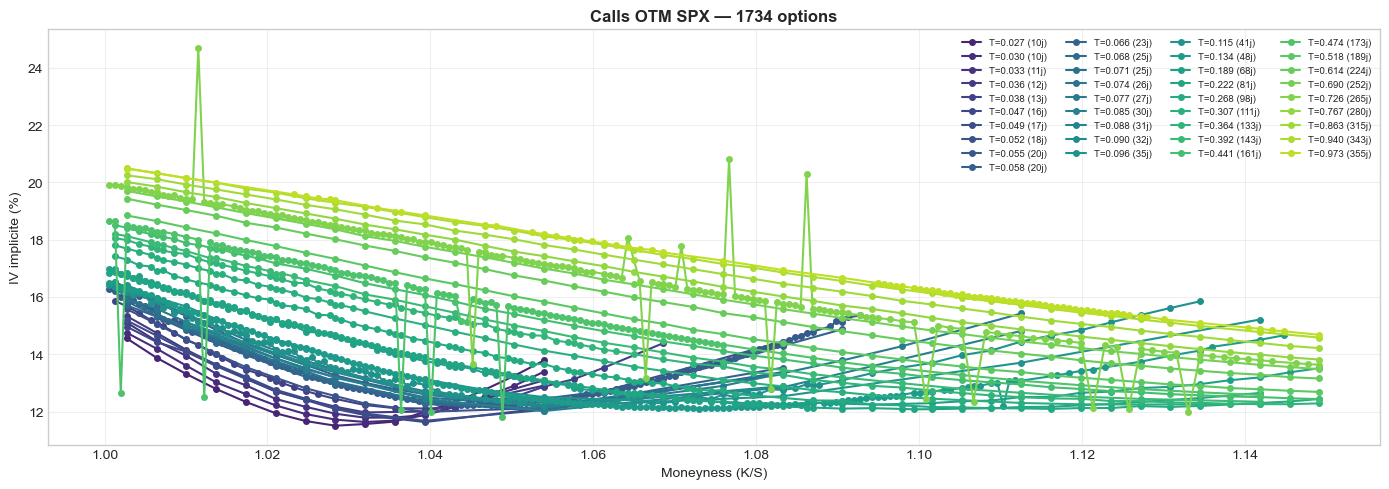

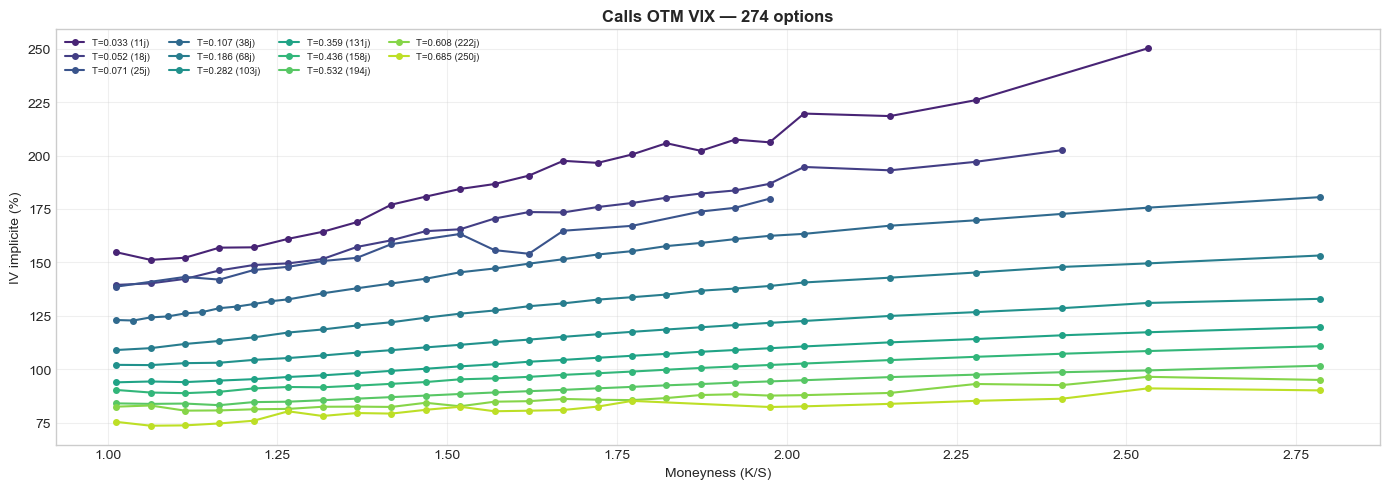

BS tools OK.


In [4]:
# ── 1.3 Smiles de marché (calls) + Outils BS ─────────────────────────
def plot_smile(data, title, spot_val, iv_col='iv_market'):
    maturities = sorted(data["T"].unique())
    colors = cm.viridis(np.linspace(0.1, 0.9, len(maturities)))
    fig, ax = plt.subplots(figsize=(14, 5))
    for T, c in zip(maturities, colors):
        sub = data[data["T"]==T].sort_values("moneyness")
        if len(sub) > 1:
            ax.plot(sub["moneyness"], sub[iv_col]*100, "o-", color=c, ms=4,
                    label=f"T={T:.3f} ({int(T*365)}j)")
    ax.set_xlabel("Moneyness (K/S)"); ax.set_ylabel("IV implicite (%)")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=7, ncol=4); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_smile(spx_data, f"Calls OTM SPX — {len(spx_data)} options", S0_SPX)
if not vix_data.empty:
    plot_smile(vix_data, f"Calls OTM VIX — {len(vix_data)} options", S0_VIX)

# ── Outils Black-Scholes ──────────────────────────────────────────────
def bs_call_price(S, K, T, r, q, sigma):
    if sigma<1e-6 or T<1e-6: return max(S*np.exp(-q*T)-K*np.exp(-r*T), 0.0)
    sqT=np.sqrt(T); d1=(np.log(S/K)+(r-q+0.5*sigma**2)*T)/(sigma*sqT); d2=d1-sigma*sqT
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def bs_vega(S, K, T, r, q, sigma):
    if sigma<1e-6 or T<1e-6: return 1e-6
    sqT=np.sqrt(T); d1=(np.log(S/K)+(r-q+0.5*sigma**2)*T)/(sigma*sqT)
    return S*np.exp(-q*T)*norm.pdf(d1)*sqT

def implied_vol_call(price, S, K, T, r, q):
    try:
        if price <= max(bs_call_price(S,K,T,r,q,1e-6), 0.0)+1e-6: return np.nan
        return brentq(lambda s: bs_call_price(S,K,T,r,q,s)-price, 1e-6, 5.0, xtol=1e-6)
    except (ValueError, RuntimeError): return np.nan

print("BS tools OK.")


# ---
# ## 2. Modèle SABR
# 
# $$dF_t = \sigma_t F_t^\beta\,dW_t^1 \qquad d\sigma_t = \alpha\sigma_t\,dW_t^2 \qquad \langle W^1,W^2\rangle_t = \rho\,t$$
# 
# | Étape | Méthode |
# |-------|---------|
# | **Hagan robuste** | Correction z→0 stable + garde-fou correction temporelle |
# | **Calibration standard** | Warm start : `diff_evo` (T₁) → `L-BFGS-B` (T₂…Tₙ) |
# | **Calibration jointe** | Loss SPX + λ·RMSE_VIX_MC par tranche | 
# | **VIX MC** | Euler explicite + frontière absorbante (β<1) · 100 000 paths |


---
## 2. Modèle SABR

$$dF_t = \sigma_t F_t^\beta\,dW_t^1 \qquad d\sigma_t = \alpha\sigma_t\,dW_t^2 \qquad \langle W^1,W^2\rangle_t = \rho\,t$$

Le modèle SABR est calibré **maturité par maturité** sur les smiles SPX.  
Nous retenons ensuite une version **jointe SPX + VIX**, où les paramètres sont ajustés en ajoutant une pénalité liée au fit des options VIX.

| Étape | Méthode |
|-------|---------|
| **Formule fermée SPX** | approximation de Hagan avec traitement robuste du cas ATM |
| **Calibration standard** | recherche de $\beta^\*$ puis calibration tranche par tranche avec warm start |
| **Calibration jointe** | perte = erreur SPX + pénalité VIX |
| **Pricing VIX** | simulation Monte Carlo sur la variance instantanée implicite de SABR |

Dans cette implémentation, le Monte Carlo est **allégé** pour rester compatible avec une machine standard, tout en conservant une comparaison cohérente entre variantes standard et jointes.

In [5]:
# ── 2.1 Formule de Hagan (2002) robuste ───────────────────────────────
def sabr_iv_hagan(F, K, T, sigma0, alpha, beta, rho):
    if T<1e-6 or sigma0<1e-6 or alpha<1e-6:
        return max(sigma0/max(F,1e-6)**(1-beta), 1e-6)
    one_m_b=1.0-beta; FK=F*K; FK_mid=np.sqrt(FK)
    time_corr=max(1.0+T*(
        (one_m_b**2*sigma0**2)/(24.0*FK_mid**(2*one_m_b))
        +(rho*beta*alpha*sigma0)/(4.0*FK_mid**one_m_b)
        +(2.0-3.0*rho**2)/24.0*alpha**2), 1e-6)
    if abs(F-K) < 1e-6*F:
        return max(sigma0/FK_mid**one_m_b*time_corr, 1e-6)
    log_FK=np.log(F/K); FK_pow=FK_mid**one_m_b
    denom=FK_pow*(1.0+one_m_b**2/24.0*log_FK**2+one_m_b**4/1920.0*log_FK**4)
    z=(alpha/sigma0)*FK_pow*log_FK
    if abs(z)<1e-6: zxz=1.0-0.5*rho*z
    else:
        disc=np.sqrt(max(1.0-2.0*rho*z+z**2,1e-6))
        arg=(disc+z-rho)/max(1.0-rho,1e-6); xz=np.log(max(arg,1e-6))
        zxz=z/xz if abs(xz)>1e-6 else 1.0
    return max((sigma0/denom)*zxz*time_corr, 1e-6)

# ── 2.2 Simulation SABR + pricing VIX calls ───────────────────────────
def simulate_sabr_paths(F0, sigma0, alpha, beta, rho, T_end, N_steps, N_paths, seed=42):
    rng=np.random.default_rng(seed); dt=T_end/N_steps; sqdt=np.sqrt(dt)
    F=np.full(N_paths,float(max(F0,1e-6))); sig=np.full(N_paths,float(max(sigma0,1e-6)))
    absorbed=np.zeros(N_paths,dtype=bool)
    def _iv(F_,s_,ab_):
        sF=np.where(ab_,1.0,np.maximum(F_,1e-6))
        return np.where(ab_,0.0,np.clip(s_*sF**(beta-1),1e-6,5.0)**2)
    iv_arr=np.zeros((N_steps+1,N_paths)); iv_arr[0]=_iv(F,sig,absorbed)
    for n in range(N_steps):
        Z1=rng.standard_normal(N_paths)
        Z2=rho*Z1+np.sqrt(1.0-rho**2)*rng.standard_normal(N_paths)
        Fb=np.where(absorbed,0.0,sig*np.maximum(F,0.0)**beta)
        F=F+Fb*sqdt*Z1; absorbed|=(F<=0.0); F=np.where(absorbed,0.0,F)
        sig=sig*np.exp(-0.5*alpha**2*dt+alpha*sqdt*Z2)
        iv_arr[n+1]=_iv(F,sig,absorbed)
    return iv_arr

def price_vix_calls_sabr(T_option, K_arr, params_dict, maturities, N_paths=5000, seed=42):
    """Pricing calls VIX sous SABR par MC (100 000 paths par défaut)."""
    T_c=min(maturities,key=lambda t:abs(t-T_option)); p=params_dict[T_c]
    T_tot=T_option+Delta_VIX; N_steps=max(int(T_tot*500),200); dt=T_tot/N_steps
    iv_arr=simulate_sabr_paths(p['F'],p['sigma0'],p['alpha'],p['beta'],p['rho'],
                                T_tot,N_steps,N_paths,seed=seed)
    idx_T=int(round(T_option/dt)); idx_end=min(int(round(T_tot/dt)),N_steps)
    if idx_T>=idx_end: return np.full(len(K_arr),np.nan), np.array([])
    integ=np.trapz(iv_arr[idx_T:idx_end+1],dx=dt,axis=0)
    VIX_T=np.sqrt(np.maximum(integ/Delta_VIX,0.0))*100.0
    disc=np.exp(-r_rate*T_option)
    return np.array([disc*np.mean(np.maximum(VIX_T-K,0.0)) for K in K_arr]), VIX_T

# ── 2.3 Calibration standard (warm start) ─────────────────────────────
def calibrate_slice_sabr(F, T, strikes, iv_mkt, beta, x0_warm=None):
    def obj(p):
        s0,al,rh=p; err=0.0
        for K,iv in zip(strikes,iv_mkt):
            try:
                im=sabr_iv_hagan(F,K,T,s0,al,beta,rh)
                err+=(im-iv)**2 if (np.isfinite(im) and im>0) else 0.01
            except: err+=0.01
        return err
    iv_atm=np.interp(F,strikes,iv_mkt); s0_i=iv_atm*F**(1-beta)
    s0_max=max(20.0,s0_i*5.0); bnds=[(1e-4,s0_max),(1e-4,5.0),(-0.999,0.999)]
    if x0_warm is None:
        x0=[np.clip(s0_i,1e-3,s0_max*0.9),0.3,-0.3]
        res=differential_evolution(obj,bnds,x0=x0,maxiter=100,tol=1e-6,seed=42,popsize=5,mutation=(0.5,1.5))
    else:
        x0=np.clip(x0_warm,[b[0] for b in bnds],[b[1] for b in bnds])
        res=minimize(obj,x0,method='L-BFGS-B',bounds=bnds,
                     options={'maxiter':100,'ftol':1e-6,'gtol':1e-6})
    s0,al,rh=res.x
    iv_m=np.array([sabr_iv_hagan(F,K,T,s0,al,beta,rh) for K in strikes])
    v=np.isfinite(iv_m)&(iv_m>0)
    rmse=np.sqrt(np.mean((iv_m[v]-iv_mkt[v])**2))*100 if v.any() else 999.0
    return (s0,al,rh),rmse,res.x

def calibrate_all_sabr(spx_df, beta, verbose=False):
    mats=sorted(spx_df["T"].unique()); te=0.0; nt=0; pd_={}; xp=None
    for i,T in enumerate(mats):
        sub=spx_df[spx_df["T"]==T].sort_values("strike")
        st=sub["strike"].values; iv=sub["iv_market"].values
        if len(st)<3: continue
        F=S0_SPX*np.exp((r_rate-q_div)*T)
        (s0,al,rh),rmse,xp=calibrate_slice_sabr(F,T,st,iv,beta,xp)
        im=np.array([sabr_iv_hagan(F,K,T,s0,al,beta,rh) for K in st])
        v=np.isfinite(im)&(im>0); te+=np.sum((im[v]-iv[v])**2); nt+=v.sum()
        pd_[T]={'sigma0':s0,'alpha':al,'rho':rh,'beta':beta,'F':F,'rmse':rmse}
        if verbose: print(f"  {'[global]' if i==0 else '[warm]  '} T={T:.4f} → RMSE={rmse:.3f}pp")
    return pd_, np.sqrt(te/max(nt,1))*100

print("Fonctions SABR prêtes.")

Fonctions SABR prêtes.


Recherche β*...
β        RMSE(pp)         Temps(s)
0.0      0.8844           2.2
0.1      0.7279           2.2
0.2      0.4567           2.3
0.3      0.4105           2.4
0.4      0.3984           2.4
0.5      0.3956           2.7
0.6      0.3893           2.4
0.7      0.3879           2.3
0.8      0.3894           2.4
0.9      0.3927           2.3
1.0      0.4628           2.4

=> β* = 0.7 | RMSE = 0.3879pp | 26s


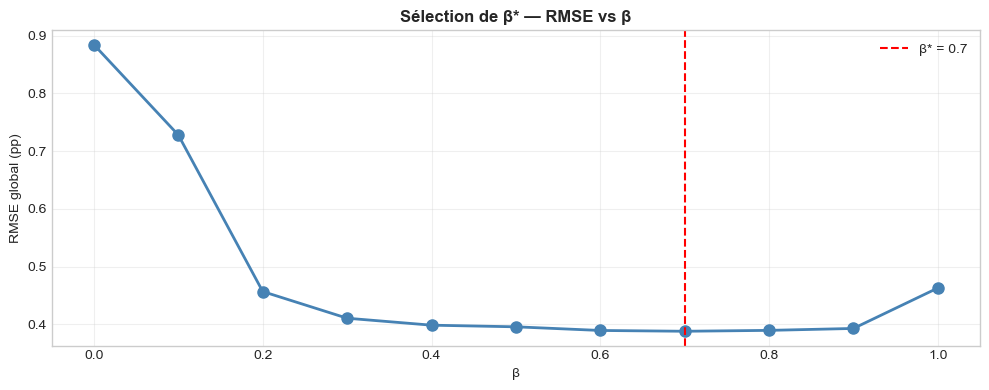

In [6]:
# ── 2.4 Recherche β* ──────────────────────────────────────────────────
print("Recherche β*..."); print(f"{'β':<8} {'RMSE(pp)':<16} {'Temps(s)'}")
beta_results={}; t0t=time.time()
for bv in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:
    t0=time.time(); _,rg=calibrate_all_sabr(spx_data,bv); dt=time.time()-t0
    beta_results[bv]=rg; print(f"{bv:<8.1f} {rg:<16.4f} {dt:.1f}")
beta_opt=min(beta_results,key=beta_results.get); t_search=time.time()-t0t
print(f"\n=> β* = {beta_opt:.1f} | RMSE = {beta_results[beta_opt]:.4f}pp | {t_search:.0f}s")

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(list(beta_results.keys()),list(beta_results.values()),"o-",color="steelblue",lw=2,ms=8)
ax.axvline(beta_opt,color="red",ls="--",lw=1.5,label=f"β* = {beta_opt:.1f}")
ax.set_xlabel("β"); ax.set_ylabel("RMSE global (pp)")
ax.set_title("Sélection de β* — RMSE vs β",fontweight="bold"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()



Calibration SABR standard β*=0.7...
  [global] T=0.0274 → RMSE=0.273pp
  [warm]   T=0.0301 → RMSE=0.173pp
  [warm]   T=0.0329 → RMSE=0.106pp
  [warm]   T=0.0356 → RMSE=0.060pp
  [warm]   T=0.0384 → RMSE=0.119pp
  [warm]   T=0.0466 → RMSE=0.240pp
  [warm]   T=0.0493 → RMSE=0.226pp
  [warm]   T=0.0521 → RMSE=0.254pp
  [warm]   T=0.0548 → RMSE=0.156pp
  [warm]   T=0.0575 → RMSE=0.138pp
  [warm]   T=0.0658 → RMSE=0.063pp
  [warm]   T=0.0685 → RMSE=0.097pp
  [warm]   T=0.0712 → RMSE=0.069pp
  [warm]   T=0.0740 → RMSE=0.092pp
  [warm]   T=0.0767 → RMSE=0.117pp
  [warm]   T=0.0849 → RMSE=0.160pp
  [warm]   T=0.0877 → RMSE=0.202pp
  [warm]   T=0.0904 → RMSE=0.215pp
  [warm]   T=0.0959 → RMSE=0.120pp
  [warm]   T=0.1151 → RMSE=0.177pp
  [warm]   T=0.1342 → RMSE=0.081pp
  [warm]   T=0.1890 → RMSE=0.051pp
  [warm]   T=0.2219 → RMSE=0.042pp
  [warm]   T=0.2685 → RMSE=0.052pp
  [warm]   T=0.3068 → RMSE=0.064pp
  [warm]   T=0.3644 → RMSE=0.046pp
  [warm]   T=0.3918 → RMSE=0.036pp
  [warm]   T=0.4411

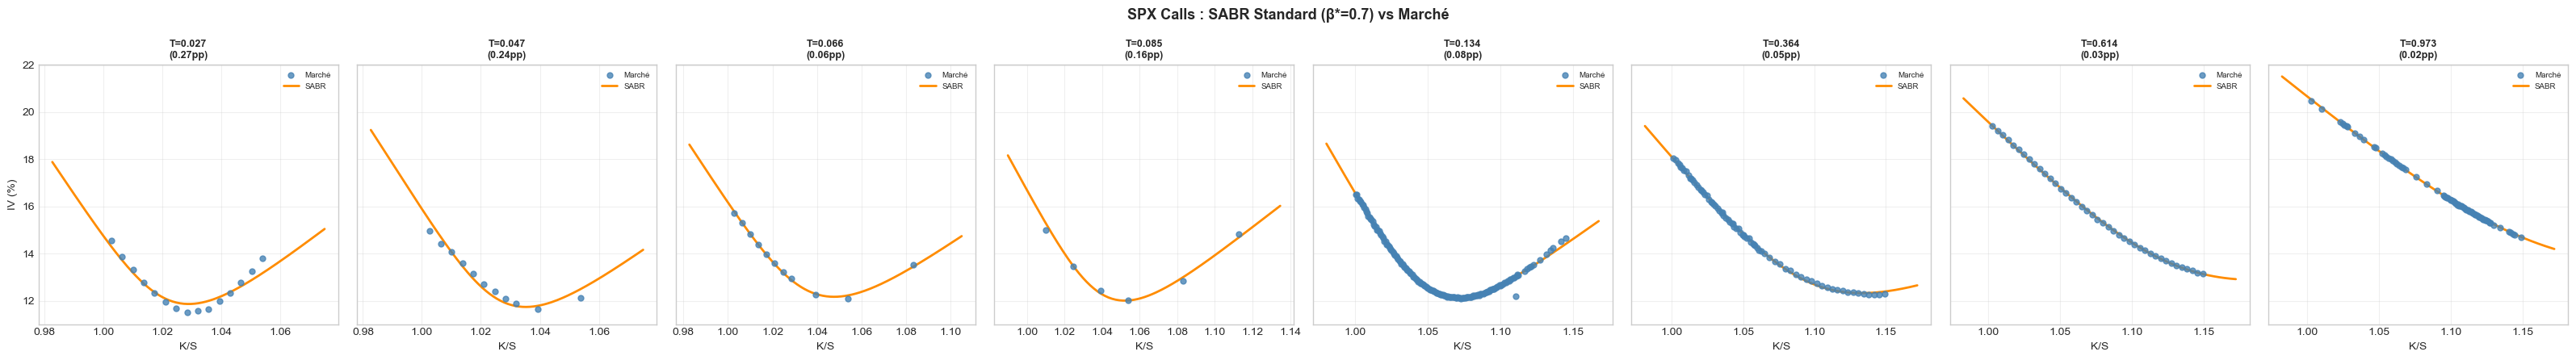

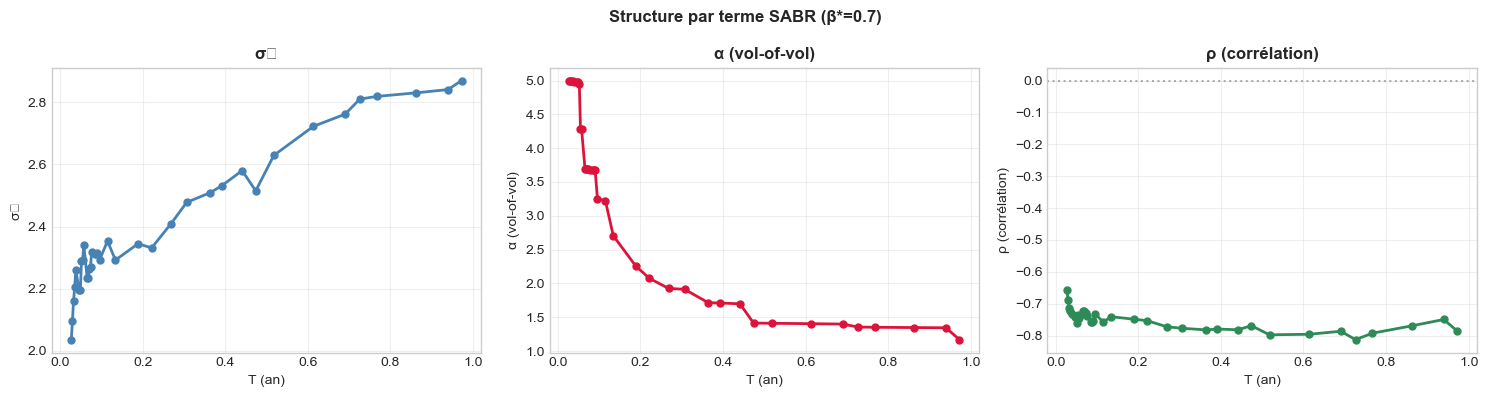

In [7]:
# ── 2.5 Calibration SABR Standard + Smiles SPX ───────────────────────
print(f"Calibration SABR standard β*={beta_opt}..."); t0=time.time()
sabr_params,rmse_sabr=calibrate_all_sabr(spx_data,beta_opt,verbose=True)
t_sabr=time.time()-t0; mats_spx=sorted(sabr_params.keys())
print(f"  SABR calibré : RMSE={rmse_sabr:.3f}pp | {t_sabr:.1f}s")

# Smiles SPX
n_show=min(len(mats_spx),8)
mats_viz=[mats_spx[i] for i in np.linspace(0,len(mats_spx)-1,n_show).astype(int)]
fig,axes=plt.subplots(1,n_show,figsize=(4*n_show,4.5),sharey=True)
if n_show==1: axes=[axes]
for col,T in enumerate(mats_viz):
    p=sabr_params[T]; sub=spx_data[spx_data["T"]==T].sort_values("moneyness")
    K_sm=np.linspace(sub["strike"].min()*0.98,sub["strike"].max()*1.02,150)
    mono=K_sm/S0_SPX
    iv_s=np.array([sabr_iv_hagan(p['F'],K,T,p['sigma0'],p['alpha'],beta_opt,p['rho']) for K in K_sm])
    ax=axes[col]
    ax.scatter(sub["moneyness"],sub["iv_market"]*100,c="steelblue",s=25,zorder=5,label="Marché",alpha=0.8)
    v=np.isfinite(iv_s)&(iv_s>0); ax.plot(mono[v],iv_s[v]*100,"darkorange",lw=2,label="SABR")
    ax.set_title(f"T={T:.3f}\n({p['rmse']:.2f}pp)",fontsize=9,fontweight="bold")
    if col==0: ax.set_ylabel("IV (%)")
    ax.set_xlabel("K/S"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle(f"SPX Calls : SABR Standard (β*={beta_opt}) vs Marché",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.show()

# Structure par terme
T_arr=np.array(mats_spx)
fig,axes=plt.subplots(1,3,figsize=(15,4))
for ax,(arr,name,color) in zip(axes,[
    (np.array([sabr_params[T]['sigma0'] for T in T_arr]),"σ₀","steelblue"),
    (np.array([sabr_params[T]['alpha']  for T in T_arr]),"α (vol-of-vol)","crimson"),
    (np.array([sabr_params[T]['rho']    for T in T_arr]),"ρ (corrélation)","seagreen")]):
    ax.plot(T_arr,arr,"o-",color=color,lw=2,ms=5); ax.set_xlabel("T (an)"); ax.set_ylabel(name)
    ax.set_title(name,fontweight="bold"); ax.grid(alpha=0.3)
axes[2].axhline(0,color="k",ls=":",alpha=0.3)
plt.suptitle(f"Structure par terme SABR (β*={beta_opt})",fontsize=12,fontweight="bold")
plt.tight_layout(); plt.show()

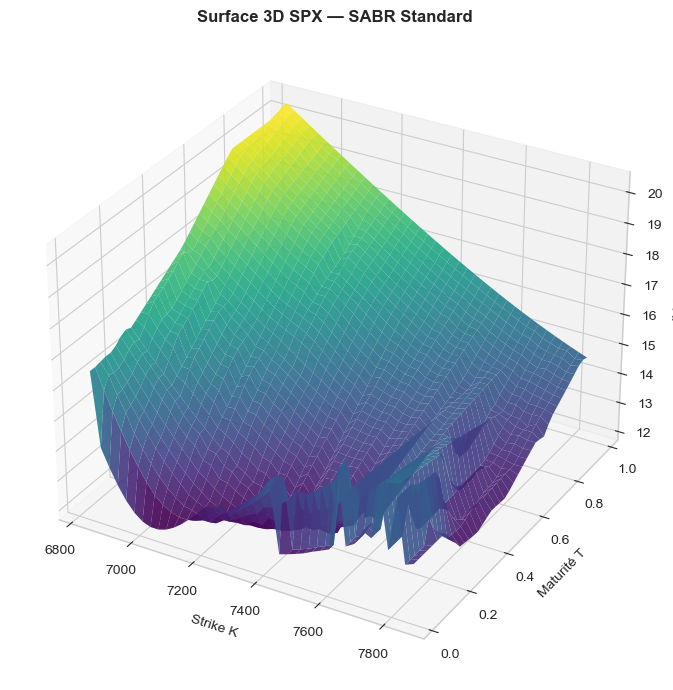

In [8]:
# ── 2.5bis Surface 3D SPX — SABR Standard ────────────────────────────
surf_rows = []
for _, row in spx_data.iterrows():
    Tc = min(sabr_params.keys(), key=lambda t: abs(t - row["T"]))
    p = sabr_params[Tc]
    iv_mod = sabr_iv_hagan(
        p["F"], row["strike"], row["T"],
        p["sigma0"], p["alpha"], beta_opt, p["rho"]
    )
    if np.isfinite(iv_mod):
        surf_rows.append([row["strike"], row["T"], iv_mod * 100])

surf_sabr = pd.DataFrame(surf_rows, columns=["strike", "T", "iv"])

K_grid = np.linspace(surf_sabr["strike"].min(), surf_sabr["strike"].max(), 40)
T_grid = np.linspace(surf_sabr["T"].min(), surf_sabr["T"].max(), 40)
KK, TT = np.meshgrid(K_grid, T_grid)

ZZ = griddata(
    (surf_sabr["strike"], surf_sabr["T"]),
    surf_sabr["iv"],
    (KK, TT),
    method="linear"
)

# Remplit les trous éventuels
ZZ_nearest = griddata(
    (surf_sabr["strike"], surf_sabr["T"]),
    surf_sabr["iv"],
    (KK, TT),
    method="nearest"
)
ZZ = np.where(np.isnan(ZZ), ZZ_nearest, ZZ)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(KK, TT, ZZ, cmap="viridis", alpha=0.9)
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel("IV (%)")
ax.set_title("Surface 3D SPX — SABR Standard", fontweight="bold")
plt.tight_layout()
plt.show()

Pricing VIX calls SABR standard ...


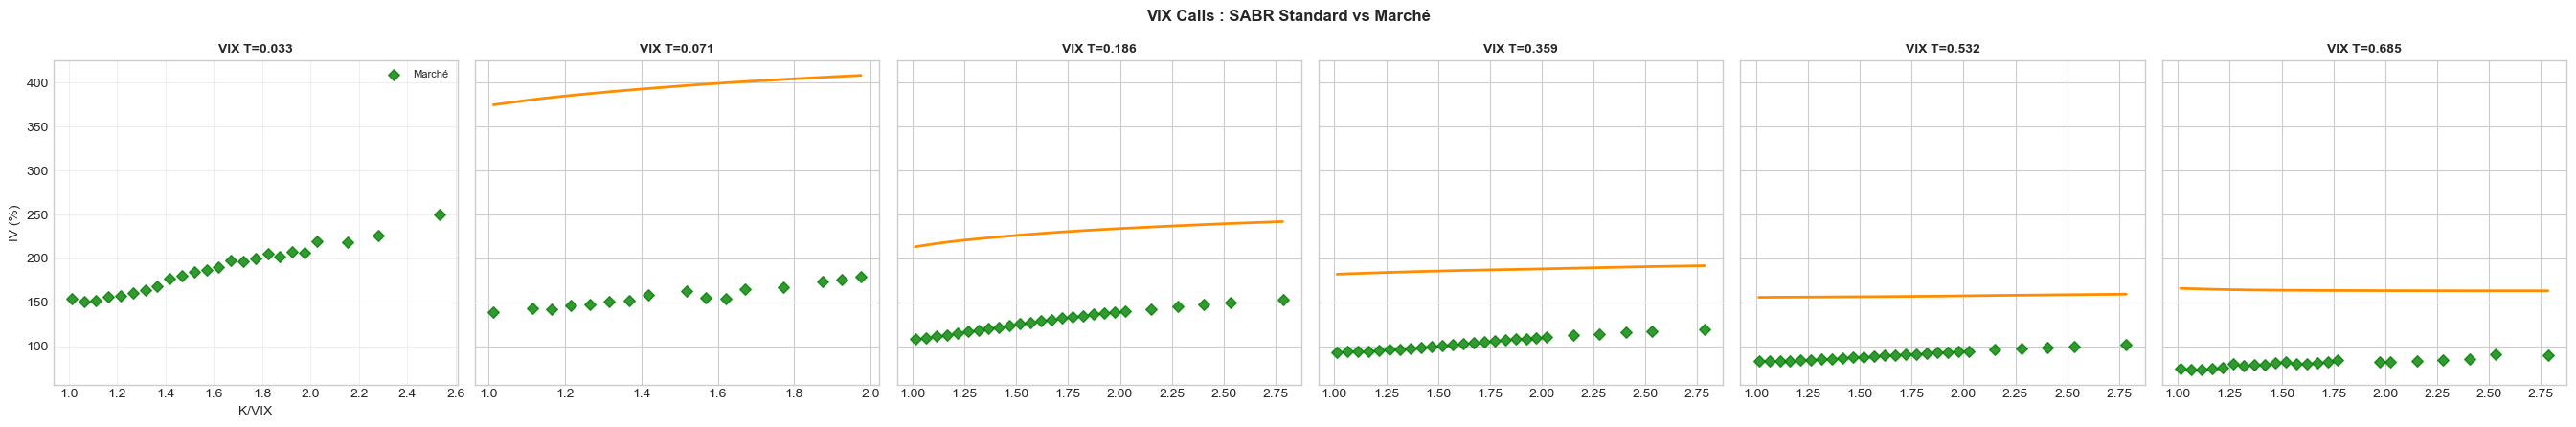

  -> 4s | RMSE VIX = 117.051pp


In [9]:
# ── 2.6 VIX Calls — SABR Standard (MC allégé) ────────────────────
if not vix_data.empty:
    print("Pricing VIX calls SABR standard ..."); t0=time.time()
    fig,axes=plt.subplots(1,n_mats_vix_viz,figsize=(4.5*n_mats_vix_viz,4.5),sharey=True)
    if n_mats_vix_viz==1: axes=[axes]
    err_sabr_vix=[]
    for col,T_vix in enumerate(mats_vix_viz):
        sub=vix_data[vix_data["T"]==T_vix].sort_values("moneyness")
        all_K=sub["strike"].values; mono=all_K/S0_VIX
        if len(all_K)==0: continue
        prices,VIX_T=price_vix_calls_sabr(T_vix,all_K,sabr_params,list(sabr_params.keys()),
                                           N_paths=10000,seed=42)
        iv_s=np.array([implied_vol_call(max(p,0),S0_VIX,K,T_vix,r_rate,0.0)
                        for p,K in zip(prices,all_K)])
        for p,K,iv_mkt in zip(prices,all_K,sub["iv_market"].values):
            iv_m=implied_vol_call(max(p,0),S0_VIX,K,T_vix,r_rate,0.0)
            if np.isfinite(iv_m): err_sabr_vix.append(abs(iv_mkt-iv_m))
        ax=axes[col]
        ax.scatter(mono,sub["iv_market"]*100,c="green",marker="D",s=35,zorder=5,label="Marché",alpha=0.8)
        v=np.isfinite(iv_s)&(iv_s>0.01)
        if v.any():
            si=np.argsort(mono[v]); ax.plot(mono[v][si],(iv_s[v]*100)[si],"darkorange",lw=2,label="SABR MC")
        ax.set_title(f"VIX T={T_vix:.3f}",fontsize=10,fontweight="bold")
        if col==0: ax.set_ylabel("IV (%)"); ax.set_xlabel("K/VIX"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle("VIX Calls : SABR Standard vs Marché",fontsize=12,fontweight="bold")
    plt.tight_layout(); plt.show()
    rmse_sabr_vix=np.sqrt(np.mean(np.array(err_sabr_vix)**2))*100 if err_sabr_vix else np.nan
    print(f"  -> {time.time()-t0:.0f}s | RMSE VIX = {rmse_sabr_vix:.3f}pp")
else: print("Pas de données VIX.")


In [10]:
# ── 2.7 Calibration SABR Jointe (SPX + pénalité VIX) ─────────────────
# Loss = RMSE_SPX + λ_VIX × RMSE_VIX_MC par tranche de maturité
LAMBDA_VIX_SABR=0.40; N_PATHS_SABR_J=3000 ; T_MATCH = 0.15 # 3k paths pour MacBook Air; T_MATCH=0.15

def calibrate_slice_joint_sabr(F,T,strikes,iv_mkt,beta,vix_sub=None,
                                lam=LAMBDA_VIX_SABR,n_vix=N_PATHS_SABR_J,x0w=None):
    def obj(p):
        s0,al,rh=p; err=0.0
        for K,iv in zip(strikes,iv_mkt):
            try:
                im=sabr_iv_hagan(F,K,T,s0,al,beta,rh)
                err+=(im-iv)**2 if (np.isfinite(im) and im>0) else 0.01
            except: err+=0.01
        if vix_sub is None or len(vix_sub)==0 or lam==0: return err
        ptmp={T:{'sigma0':s0,'alpha':al,'rho':rh,'beta':beta,'F':F,'rmse':0.0}}
        aK=vix_sub["strike"].values; T_v=float(vix_sub["T"].iloc[0])
        pv,_=price_vix_calls_sabr(T_v,aK,ptmp,[T],N_paths=n_vix,seed=0)
        ev=0.0
        for pval,K,iv_v in zip(pv,aK,vix_sub["iv_market"].values):
            if not np.isfinite(pval) or pval<=0: ev+=0.01; continue
            iv_mod=implied_vol_call(pval,S0_VIX,K,T_v,r_rate,0.0)
            ev+=(iv_mod-iv_v)**2 if np.isfinite(iv_mod) else 0.01
        return err + lam*ev

    iv_atm=np.interp(F,strikes,iv_mkt); s0_i=iv_atm*F**(1-beta)
    s0_max=max(20.0,s0_i*5.0); bnds=[(1e-4,s0_max),(1e-4,5.0),(-0.999,0.999)]
    if x0w is None:
        x0=[np.clip(s0_i,1e-3,s0_max*0.9),0.3,-0.3]
        res=differential_evolution(obj,bnds,x0=x0,maxiter=100,tol=1e-6,seed=42,popsize=5,mutation=(0.5,1.5))
    else:
        x0=np.clip(x0w,[b[0] for b in bnds],[b[1] for b in bnds])
        res=minimize(obj,x0,method='L-BFGS-B',bounds=bnds,options={'maxiter':100,'ftol':1e-6,'gtol':1e-6})
    s0,al,rh=res.x
    im=np.array([sabr_iv_hagan(F,K,T,s0,al,beta,rh) for K in strikes])
    v=np.isfinite(im)&(im>0)
    rmse=np.sqrt(np.mean((im[v]-iv_mkt[v])**2))*100 if v.any() else 999.0
    return (s0,al,rh),rmse,res.x

def calibrate_all_sabr_joint(spx_df,vix_df,beta,lam=LAMBDA_VIX_SABR,n_vix=N_PATHS_SABR_J,T_match=T_MATCH):
    mats=sorted(spx_df["T"].unique())
    vm=sorted(vix_df["T"].unique()) if not vix_df.empty else []
    te=0.0; nt=0; pd_={}; xp=None
    for i,T in enumerate(mats):
        sub=spx_df[spx_df["T"]==T].sort_values("strike")
        st=sub["strike"].values; iv=sub["iv_market"].values
        if len(st)<3: continue
        F=S0_SPX*np.exp((r_rate-q_div)*T)
        vsub=None
        if vm:
            Tv=min(vm,key=lambda t:abs(t-T))
            if abs(Tv-T)<T_match:
                vsub=vix_df[vix_df["T"]==Tv].copy()
                if len(vsub)==0: vsub=None
        (s0,al,rh),rmse,xp=calibrate_slice_joint_sabr(F,T,st,iv,beta,vsub,lam,n_vix,xp)
        im=np.array([sabr_iv_hagan(F,K,T,s0,al,beta,rh) for K in st])
        v=np.isfinite(im)&(im>0); te+=np.sum((im[v]-iv[v])**2); nt+=v.sum()
        pd_[T]={'sigma0':s0,'alpha':al,'rho':rh,'beta':beta,'F':F,'rmse':rmse}
        n_vp=len(vsub) if vsub is not None else 0
        tag="[global+VIX]" if(i==0 and n_vp>0) else "[warm+VIX] " if n_vp>0 else "[warm]     "
        print(f"  {tag} T={T:.4f} → RMSE_SPX={rmse:.3f}pp | VIX_pts={n_vp}")
    return pd_, np.sqrt(te/max(nt,1))*100

print(f"Fonctions SABR joint prêtes. λ={LAMBDA_VIX_SABR} | N_MC={N_PATHS_SABR_J} | T_match={T_MATCH}")


Fonctions SABR joint prêtes. λ=0.4 | N_MC=3000 | T_match=0.15


  SABR JOINT | β*=0.7 | λ_VIX=0.4
  [global+VIX] T=0.0274 → RMSE_SPX=0.886pp | VIX_pts=24
  [warm+VIX]  T=0.0301 → RMSE_SPX=0.845pp | VIX_pts=24
  [warm+VIX]  T=0.0329 → RMSE_SPX=0.983pp | VIX_pts=24
  [warm+VIX]  T=0.0356 → RMSE_SPX=1.088pp | VIX_pts=24
  [warm+VIX]  T=0.0384 → RMSE_SPX=1.373pp | VIX_pts=24
  [warm+VIX]  T=0.0466 → RMSE_SPX=0.948pp | VIX_pts=24
  [warm+VIX]  T=0.0493 → RMSE_SPX=1.021pp | VIX_pts=24
  [warm+VIX]  T=0.0521 → RMSE_SPX=1.333pp | VIX_pts=24
  [warm+VIX]  T=0.0548 → RMSE_SPX=1.484pp | VIX_pts=24
  [warm+VIX]  T=0.0575 → RMSE_SPX=1.942pp | VIX_pts=24
  [warm+VIX]  T=0.0658 → RMSE_SPX=1.978pp | VIX_pts=16
  [warm+VIX]  T=0.0685 → RMSE_SPX=1.917pp | VIX_pts=16
  [warm+VIX]  T=0.0712 → RMSE_SPX=1.864pp | VIX_pts=16
  [warm+VIX]  T=0.0740 → RMSE_SPX=1.788pp | VIX_pts=16
  [warm+VIX]  T=0.0767 → RMSE_SPX=1.550pp | VIX_pts=16
  [warm+VIX]  T=0.0849 → RMSE_SPX=2.154pp | VIX_pts=16
  [warm+VIX]  T=0.0877 → RMSE_SPX=2.194pp | VIX_pts=16
  [warm+VIX]  T=0.0904 → RMSE_

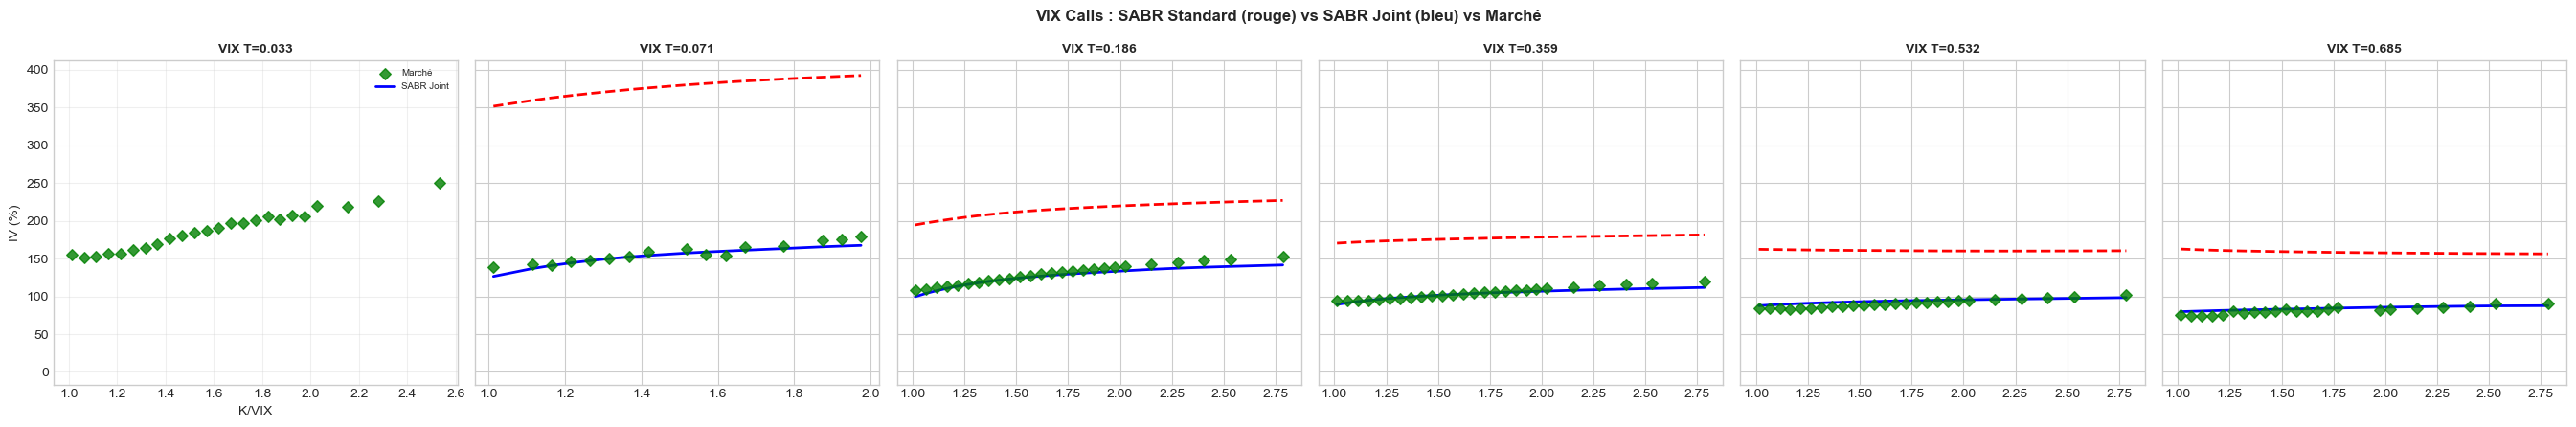

  RMSE VIX  Standard : 107.740pp | Joint : 14.690pp


In [11]:
# ── 2.8 Calibration SABR Jointe + VIX Standard vs Joint ──────────────
print("="*60); print(f"  SABR JOINT | β*={beta_opt} | λ_VIX={LAMBDA_VIX_SABR}"); print("="*60)
t0=time.time()
sabr_params_j,rmse_sabr_j=calibrate_all_sabr_joint(spx_data,vix_data,beta_opt)
t_sabr_j=time.time()-t0; mats_j=sorted(sabr_params_j.keys())
print(f"  Joint : RMSE_SPX={rmse_sabr_j:.3f}pp | {t_sabr_j:.0f}s")

# VIX : Standard vs Joint vs Marché
if not vix_data.empty:
    err_std=[]; err_jnt=[]
    fig,axes=plt.subplots(1,n_mats_vix_viz,figsize=(4.5*n_mats_vix_viz,4.5),sharey=True)
    if n_mats_vix_viz==1: axes=[axes]
    for col,T_vix in enumerate(mats_vix_viz):
        sub=vix_data[vix_data["T"]==T_vix].sort_values("moneyness")
        all_K=sub["strike"].values; mono=all_K/S0_VIX
        if len(all_K)==0: continue
        ps,_=price_vix_calls_sabr(T_vix,all_K,sabr_params,  list(sabr_params.keys()),  N_paths=5000,seed=42)
        pj,_=price_vix_calls_sabr(T_vix,all_K,sabr_params_j,list(sabr_params_j.keys()),N_paths=5000,seed=42)
        iv_s=np.array([implied_vol_call(max(p,0),S0_VIX,K,T_vix,r_rate,0.0) for p,K in zip(ps,all_K)])
        iv_j=np.array([implied_vol_call(max(p,0),S0_VIX,K,T_vix,r_rate,0.0) for p,K in zip(pj,all_K)])
        for iv_mkt_v,vs,vj in zip(sub["iv_market"].values,iv_s,iv_j):
            if np.isfinite(vs): err_std.append(abs(iv_mkt_v-vs))
            if np.isfinite(vj): err_jnt.append(abs(iv_mkt_v-vj))
        ax=axes[col]
        ax.scatter(mono,sub["iv_market"]*100,c="green",marker="D",s=35,zorder=5,label="Marché",alpha=0.8)
        for iv_arr,style,lbl in [(iv_s,"r--","SABR Std"),(iv_j,"b-","SABR Joint")]:
            v=np.isfinite(iv_arr)&(iv_arr>0.001)
            if v.any(): si=np.argsort(mono[v]); ax.plot(mono[v][si],(iv_arr[v]*100)[si],style,lw=2,label=lbl)
        ax.set_title(f"VIX T={T_vix:.3f}",fontsize=10,fontweight="bold")
        if col==0: ax.set_ylabel("IV (%)"); ax.set_xlabel("K/VIX"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.suptitle("VIX Calls : SABR Standard (rouge) vs SABR Joint (bleu) vs Marché",fontsize=12,fontweight="bold")
    plt.tight_layout(); plt.show()
    r_std=np.sqrt(np.mean(np.array(err_std)**2))*100 if err_std else np.nan
    r_jnt=np.sqrt(np.mean(np.array(err_jnt)**2))*100 if err_jnt else np.nan
    print(f"  RMSE VIX  Standard : {r_std:.3f}pp | Joint : {r_jnt:.3f}pp")
    rmse_sabr_vix_j=r_jnt
else: print("Pas de données VIX.")


# ---
# ## 3. Modèle Heston
# 
# $$dS_t = (r-q)S_t\,dt + \sqrt{V_t}S_t\,dW_t^1 \qquad dV_t = \kappa(\theta-V_t)\,dt + \xi\sqrt{V_t}\,dW_t^2$$
# 
# ### Formule analytique exacte pour le VIX
# 
# Sous Heston, $V_T$ suit un CIR. Conditionnellement à $V_T$, le VIX est **déterministe** :
# $$\text{VIX}_T^2 = \theta + (V_T - \theta)\frac{1-e^{-\kappa\Delta}}{\kappa\Delta}$$
# 
# Cette formule est **exacte** (pas une approximation). On simule seulement $V_T$ via le schéma QE,
# pas le chemin $[T, T+\Delta]$ → zéro biais de discrétisation, landscape d'optimisation lisse.
# 
# | Étape | Méthode |
# |-------|---------|
# | **Calibration SPX** | QuantLib TRF, résidus Vega-weighted |
# | **VIX analytique** | QE(V_T) + formule exacte |
# | **Calibration jointe** | Résidus VIX analytiques dans la loss → gradient propre |


---
## 3. Modèle Heston

$$dS_t = (r-q)S_t\,dt + \sqrt{V_t}S_t\,dW_t^1 \qquad dV_t = \kappa(\theta-V_t)\,dt + \xi\sqrt{V_t}\,dW_t^2$$

### Formule analytique exacte pour le VIX

Sous Heston, la variance suit un processus de type CIR. Conditionnellement à $V_T$, le VIX futur est **déterministe** :

$$\mathrm{VIX}_T^2 = \theta + (V_T - \theta)\frac{1-e^{-\kappa\Delta}}{\kappa\Delta}$$

Cette relation est un point fort du modèle dans notre projet : il n’est **pas nécessaire de simuler le chemin complet** entre $T$ et $T+\Delta$ pour obtenir le VIX.  
On simule uniquement $V_T$ via le schéma **QE d’Andersen**, puis on applique la formule analytique.

| Étape | Méthode |
|-------|---------|
| **Calibration SPX** | calibration Heston standard avec QuantLib |
| **Pricing VIX** | simulation de $V_T$ + formule analytique exacte pour $\mathrm{VIX}_T$ |
| **Calibration jointe** | ajout des résidus VIX dans la fonction de coût |

Cette approche fournit une calibration plus structurée inter-maturités que SABR, mais le fit SPX reste dans notre snapshot moins précis que celui de SABR standard.

In [12]:
# ── 3.1 Schéma QE (Andersen 2008) + Formule analytique VIX ───────────
def simulate_heston_qe(v0, kappa, theta, sigma, T_max, N_steps, N_paths, seed=42, psi_c=1.5):
    """Quadratic Exponential — distribution CIR exacte à chaque pas."""
    rng=np.random.default_rng(seed); dt=T_max/N_steps; eKdt=np.exp(-kappa*dt)
    A=sigma**2*eKdt*(1-eKdt)/kappa; B=theta*sigma**2*(1-eKdt)**2/(2*kappa)
    V=np.zeros((N_steps+1,N_paths)); V[0]=v0
    for n in range(N_steps):
        Vc=V[n]; m=theta+(Vc-theta)*eKdt; s2=Vc*A+B; psi=s2/np.maximum(m**2,1e-6)
        Vn=np.zeros(N_paths)
        r1=psi<=psi_c
        if r1.any():
            u=2.0/psi[r1]; b2=u-1.0+np.sqrt(np.maximum(u*(u-1.0),0.0))
            a=m[r1]/(1.0+b2); Z=rng.standard_normal(r1.sum()); Vn[r1]=a*(np.sqrt(b2)+Z)**2
        r2=~r1
        if r2.any():
            psi2=psi[r2]; m2=m[r2]; pm=(psi2-1.0)/(psi2+1.0)
            be=2.0/np.maximum(m2*(psi2+1.0),1e-6); U=rng.uniform(size=r2.sum())
            Ve=np.zeros(r2.sum()); me=U>pm
            if me.any():
                Ve[me]=np.log(np.maximum((1.0-pm[me])/np.maximum(1.0-U[me],1e-6),1e-6))/np.maximum(be[me],1e-6)
            Vn[r2]=Ve
        V[n+1]=np.maximum(Vn,0.0)
    return V

def heston_vix_from_V(V_arr, kappa, theta):
    """Formule analytique exacte VIX_T = f(V_T) sous Heston."""
    if abs(kappa)<1e-6: vix_sq=np.maximum(np.asarray(V_arr),0.0)
    else:
        factor=(1.0-np.exp(-kappa*Delta_VIX))/(kappa*Delta_VIX)
        vix_sq=np.maximum(theta+(np.asarray(V_arr)-theta)*factor,0.0)
    return np.sqrt(vix_sq)*100.0

def simulate_V_T(v0, kappa, theta, sigma, T, N_paths, seed=42):
    """Simule V_T via QE (valeur terminale seulement)."""
    N_steps=max(int(T*252),50)
    return simulate_heston_qe(v0,kappa,theta,sigma,T,N_steps,N_paths,seed=seed)[-1]

def price_vix_calls_heston(T_option, K_arr, v0, kappa, theta, sigma, N_paths=2000, seed=42):
    """Pricing exact calls VIX Heston : VIX_T = f(V_T) analytique."""
    V_T=simulate_V_T(v0,kappa,theta,sigma,T_option,N_paths,seed)
    VIX_T=heston_vix_from_V(V_T,kappa,theta)
    disc=np.exp(-r_rate*T_option)
    return np.array([disc*np.mean(np.maximum(VIX_T-K,0.0)) for K in K_arr]), VIX_T

def simulate_variance_fast(v0,kappa,theta,sigma,T_max,N_steps,N_paths,rng):
    dt=T_max/N_steps; V=np.zeros((N_steps+1,N_paths)); V[0]=v0
    for n in range(N_steps):
        dW=rng.standard_normal(N_paths)*np.sqrt(dt); Vc=np.maximum(V[n],0.0)
        V[n+1]=np.maximum(Vc+kappa*(theta-Vc)*dt+sigma*np.sqrt(Vc)*dW,0.0)
    return V

print("Fonctions Heston (QE + VIX analytique) prêtes.")
# Test rapide de la formule VIX
VIX_test = heston_vix_from_V(np.array([0.04,0.06,0.08]),2.0,0.04)
print(f"  Test VIX_T(V=[0.04,0.06,0.08]) = {VIX_test.round(2)} %")


Fonctions Heston (QE + VIX analytique) prêtes.
  Test VIX_T(V=[0.04,0.06,0.08]) = [20.   24.17 27.73] %


In [13]:
# ── 3.2 Calibration Heston Standard (QuantLib, Vega-weighted) ─────────
today_ql = ql.Date(MARKET_DATE.day, MARKET_DATE.month, MARKET_DATE.year)
ql.Settings.instance().evaluationDate = today_ql
calendar=ql.UnitedStates(ql.UnitedStates.GovernmentBond); dc=ql.Actual365Fixed()
flat_ts=ql.YieldTermStructureHandle(ql.FlatForward(today_ql,r_rate,dc))
div_ts =ql.YieldTermStructureHandle(ql.FlatForward(today_ql,q_div, dc))
spot_ql=ql.QuoteHandle(ql.SimpleQuote(float(S0_SPX)))

process_init=ql.HestonProcess(flat_ts,div_ts,spot_ql,0.04,2.0,0.04,0.5,-0.7)
model_ql=ql.HestonModel(process_init); engine_ql=ql.AnalyticHestonEngine(model_ql)

helpers_vega=[]
for _,row in calib_spx.iterrows():
    K,T,iv=float(row["strike"]),float(row["T"]),float(row["iv_market"])
    if iv<0.005: continue
    h=ql.HestonModelHelper(ql.Period(max(int(T*365),1),ql.Days),calendar,float(S0_SPX),K,
                            ql.QuoteHandle(ql.SimpleQuote(float(iv))),flat_ts,div_ts)
    h.setPricingEngine(engine_ql)
    helpers_vega.append((h,bs_vega(S0_SPX,K,T,r_rate,q_div,iv)))
vega_floor=np.percentile([v for _,v in helpers_vega],10)
print(f"QuantLib : {len(helpers_vega)} helpers | vega_floor={vega_floor:.6f}")

def cost_heston_spx(params):
    v0,kappa,theta,sigma,rho=params
    proc=ql.HestonProcess(flat_ts,div_ts,spot_ql,v0,kappa,theta,sigma,rho)
    mod=ql.HestonModel(proc); eng=ql.AnalyticHestonEngine(mod)
    res=[]
    for h,vg in helpers_vega:
        h.setPricingEngine(eng); res.append((h.modelValue()-h.marketValue())/max(vg,vega_floor))
    return np.array(res)

print("\n" + "="*55 + "\n  CALIBRATION HESTON STANDARD (SPX)\n" + "="*55)
t0=time.time()
res_h=least_squares(cost_heston_spx,x0=[0.04,2.0,0.04,0.5,-0.7],
                    bounds=([0.001,0.01,0.001,0.01,-0.99],[0.5,10.0,1.0,3.0,-0.01]),
                    method="trf",ftol=1e-6,xtol=1e-6,max_nfev=2000)
t_heston=time.time()-t0; v0_h,kappa_h,theta_h,sigma_h,rho_h=res_h.x
print(f"Calibré en {t_heston:.1f}s | V0={v0_h:.4f}({np.sqrt(v0_h)*100:.1f}%) κ={kappa_h:.4f} θ={theta_h:.4f}({np.sqrt(theta_h)*100:.1f}%) ξ={sigma_h:.4f} ρ={rho_h:.4f}")
print(f"RMSE residus ≈ {np.sqrt(np.mean(res_h.fun**2))*100:.3f} pts vol")

calib_proc=ql.HestonProcess(flat_ts,div_ts,spot_ql,v0_h,kappa_h,theta_h,sigma_h,rho_h)
calib_model=ql.HestonModel(calib_proc); calib_engine=ql.AnalyticHestonEngine(calib_model)

def heston_price(K,T,v0=v0_h,kappa=kappa_h,theta=theta_h,sigma=sigma_h,rho=rho_h,engine=None):
    if engine is None: engine=calib_engine
    days=max(int(T*365),1); mat_ql=today_ql+ql.Period(days,ql.Days)
    option=ql.VanillaOption(ql.PlainVanillaPayoff(ql.Option.Call,float(K)),ql.EuropeanExercise(mat_ql))
    option.setPricingEngine(engine); return option.NPV()


QuantLib : 1734 helpers | vega_floor=163.459906

  CALIBRATION HESTON STANDARD (SPX)
Calibré en 19.4s | V0=0.0403(20.1%) κ=3.8907 θ=0.0706(26.6%) ξ=2.1237 ρ=-0.7860
RMSE residus ≈ 0.769 pts vol


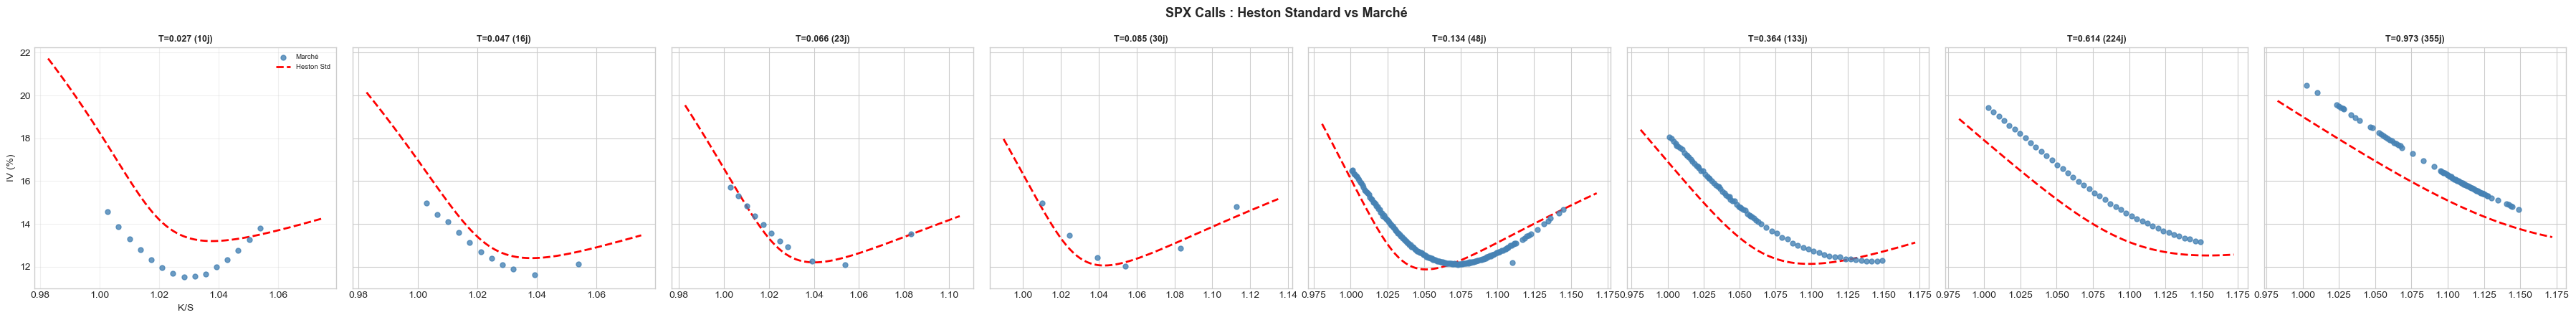

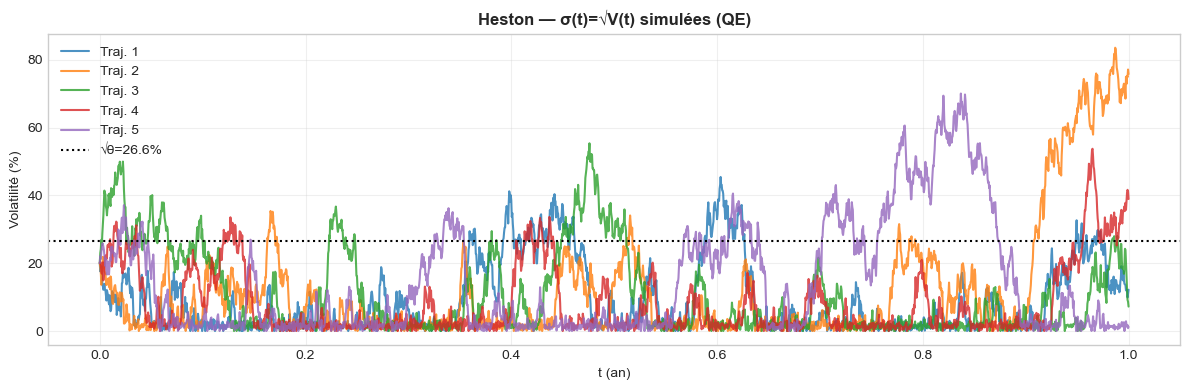

In [14]:
# ── 3.3 SPX Smiles + Trajectoires + Surface 3D ───────────────────────
mats_all=sorted(spx_data["T"].unique()); n_mats=min(len(mats_all),8)
mats_viz_h=[mats_all[i] for i in np.linspace(0,len(mats_all)-1,n_mats).astype(int)]

fig,axes=plt.subplots(1,len(mats_viz_h),figsize=(4.5*len(mats_viz_h),4.5),sharey=True)
for col,T in enumerate(mats_viz_h):
    sub=spx_data[spx_data["T"]==T].sort_values("moneyness")
    K_sm=np.linspace(sub["strike"].min()*0.98,sub["strike"].max()*1.02,80); mono=K_sm/S0_SPX
    h_iv=np.array([implied_vol_call(heston_price(K,T),S0_SPX,K,T,r_rate,q_div) for K in K_sm])
    ax=axes[col]
    ax.scatter(sub["moneyness"],sub["iv_market"]*100,c="steelblue",s=25,zorder=5,label="Marché",alpha=0.8)
    v=np.isfinite(h_iv); ax.plot(mono[v],h_iv[v]*100,"r--",lw=2,label="Heston Std")
    ax.set_title(f"T={T:.3f} ({int(T*365)}j)",fontsize=9,fontweight="bold")
    if col==0: ax.set_ylabel("IV (%)"); ax.set_xlabel("K/S"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle("SPX Calls : Heston Standard vs Marché",fontsize=13,fontweight="bold")
plt.tight_layout(); plt.show()

# Trajectoires
V_t=simulate_heston_qe(v0_h,kappa_h,theta_h,sigma_h,1.0,2000,5,seed=123)
t_g=np.linspace(0,1.0,2001)
fig,ax=plt.subplots(figsize=(12,4))
for i in range(5): ax.plot(t_g,np.sqrt(V_t[:,i])*100,alpha=0.8,lw=1.5,label=f"Traj. {i+1}")
ax.axhline(np.sqrt(theta_h)*100,color="k",ls=":",lw=1.5,label=f"√θ={np.sqrt(theta_h)*100:.1f}%")
ax.set_title("Heston — σ(t)=√V(t) simulées (QE)",fontweight="bold"); ax.legend(); ax.grid(alpha=0.3)
ax.set_xlabel("t (an)"); ax.set_ylabel("Volatilité (%)"); plt.tight_layout(); plt.show()


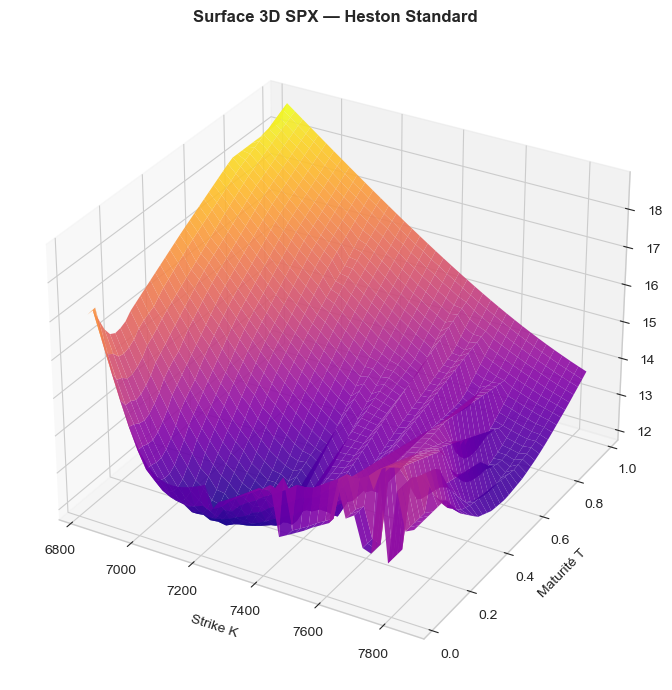

In [15]:
# ── 3.3bis Surface 3D SPX — Heston Standard ──────────────────────────
surf_rows = []
for _, row in spx_data.iterrows():
    try:
        price = heston_price(row["strike"], row["T"])
        iv_mod = implied_vol_call(
            max(price, 0.0),
            S0_SPX,
            row["strike"],
            row["T"],
            r_rate,
            q_div
        )
        if np.isfinite(iv_mod):
            surf_rows.append([row["strike"], row["T"], iv_mod * 100])
    except:
        continue

surf_heston = pd.DataFrame(surf_rows, columns=["strike", "T", "iv"])

K_grid = np.linspace(surf_heston["strike"].min(), surf_heston["strike"].max(), 40)
T_grid = np.linspace(surf_heston["T"].min(), surf_heston["T"].max(), 40)
KK, TT = np.meshgrid(K_grid, T_grid)

ZZ = griddata(
    (surf_heston["strike"], surf_heston["T"]),
    surf_heston["iv"],
    (KK, TT),
    method="linear"
)

# Remplit les trous éventuels
ZZ_nearest = griddata(
    (surf_heston["strike"], surf_heston["T"]),
    surf_heston["iv"],
    (KK, TT),
    method="nearest"
)
ZZ = np.where(np.isnan(ZZ), ZZ_nearest, ZZ)

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(KK, TT, ZZ, cmap="plasma", alpha=0.9)
ax.set_xlabel("Strike K")
ax.set_ylabel("Maturité T")
ax.set_zlabel("IV (%)")
ax.set_title("Surface 3D SPX — Heston Standard", fontweight="bold")
plt.tight_layout()
plt.show()

Pricing VIX analytique Heston standard (MC allégé)...


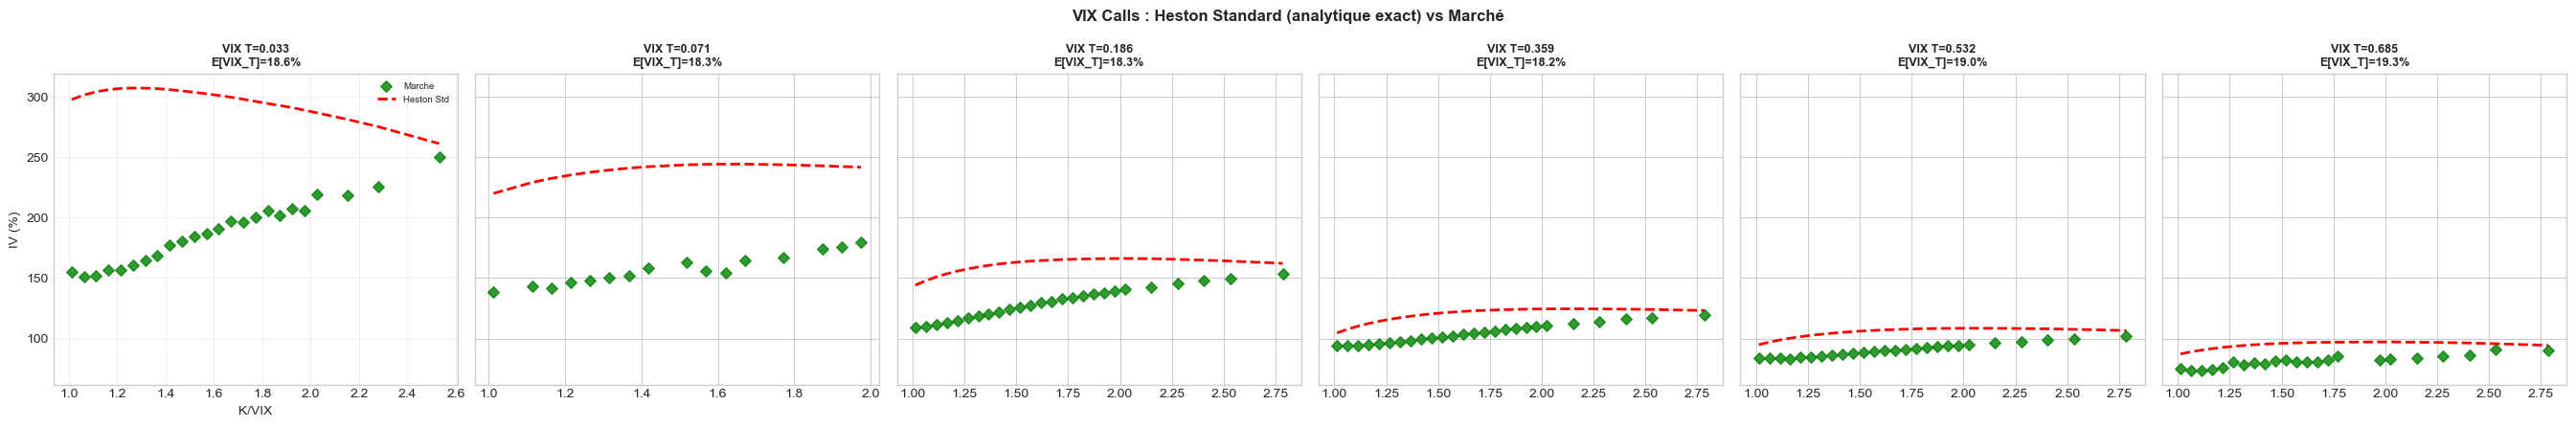

  -> 1.9s | RMSE VIX = 57.746pp


In [16]:
# ── 3.4 VIX Calls — Heston Standard (formule analytique exacte, MC allégé) ───────
if not vix_data.empty:
    print("Pricing VIX analytique Heston standard (MC allégé)..."); t0=time.time()
    err_h_vix=[]
    fig,axes=plt.subplots(1,n_mats_vix_viz,figsize=(4.5*n_mats_vix_viz,4.5),sharey=True)
    if n_mats_vix_viz==1: axes=[axes]
    for col,T_vix in enumerate(mats_vix_viz):
        sub=vix_data[vix_data["T"]==T_vix].sort_values("moneyness")
        all_K=sub["strike"].values; mono=all_K/S0_VIX
        if len(all_K)==0: continue
        prices,VIX_T=price_vix_calls_heston(T_vix,all_K,v0_h,kappa_h,theta_h,sigma_h,N_paths=5000)
        iv_h=np.array([implied_vol_call(max(p,0),S0_VIX,K,T_vix,r_rate,0.0) for p,K in zip(prices,all_K)])
        for iv_mkt_v,iv_mod in zip(sub["iv_market"].values,iv_h):
            if np.isfinite(iv_mod): err_h_vix.append(abs(iv_mkt_v-iv_mod))
        ax=axes[col]
        ax.scatter(mono,sub["iv_market"]*100,c="green",marker="D",s=35,zorder=5,label="Marché",alpha=0.8)
        v=np.isfinite(iv_h)&(iv_h>0.001)
        if v.any(): si=np.argsort(mono[v]); ax.plot(mono[v][si],(iv_h[v]*100)[si],"r--",lw=2,label="Heston Std")
        else: ax.text(0.5,0.5,"IV N/A",transform=ax.transAxes,ha='center',color='red')
        ax.set_title(f"VIX T={T_vix:.3f}\nE[VIX_T]={np.mean(VIX_T):.1f}%",fontsize=9,fontweight="bold")
        if col==0: ax.set_ylabel("IV (%)"); ax.set_xlabel("K/VIX"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.suptitle("VIX Calls : Heston Standard (analytique exact) vs Marché",fontsize=12,fontweight="bold")
    plt.tight_layout(); plt.show()
    rmse_h_vix_std=np.sqrt(np.mean(np.array(err_h_vix)**2))*100 if err_h_vix else np.nan
    print(f"  -> {time.time()-t0:.1f}s | RMSE VIX = {rmse_h_vix_std:.3f}pp")
else: print("Pas de données VIX.")


In [17]:
# ── 3.5 Calibration Jointe Heston (VIX analytique dans la loss) ───────
# Avantage vs version précédente : résidus VIX calculés analytiquement
# → pas de bruit MC dans le landscape d'optimisation → convergence bien meilleure
LAMBDA_VIX_H=0.35; N_PATHS_VIX_J=3000

vix_calib=vix_data.copy()
if len(vix_calib)>40: vix_calib=vix_calib.sample(40,random_state=42).reset_index(drop=True)
vix_mats_u=sorted(vix_calib["T"].unique())

helpers_spx_j=[(float(r["strike"]),float(r["T"]),float(r["iv_market"]),
                 bs_vega(S0_SPX,float(r["strike"]),float(r["T"]),r_rate,q_div,float(r["iv_market"])))
                for _,r in calib_spx.iterrows()]
vega_floor_spx_j=np.percentile([v for *_,v in helpers_spx_j],10)
helpers_vix_j=[(float(r["strike"]),float(r["T"]),float(r["iv_market"]),
                 bs_vega(S0_VIX,float(r["strike"]),float(r["T"]),r_rate,0.0,float(r["iv_market"])))
                for _,r in vix_calib.iterrows()]
vega_floor_vix_j=np.percentile([v for *_,v in helpers_vix_j],10) if helpers_vix_j else 1e-4
print(f"Joint setup : SPX={len(helpers_spx_j)} | VIX={len(helpers_vix_j)} | λ={LAMBDA_VIX_H}")

def cost_joint_heston_analytic(params):
    v0,kappa,theta,sigma,rho=params
    # Résidus SPX (analytique QuantLib)
    proc=ql.HestonProcess(flat_ts,div_ts,spot_ql,v0,kappa,theta,sigma,rho)
    mod=ql.HestonModel(proc); eng=ql.AnalyticHestonEngine(mod)
    res_spx=[]
    for K,T,iv_mkt,vg in helpers_spx_j:
        h=ql.HestonModelHelper(ql.Period(max(int(T*365),1),ql.Days),calendar,float(S0_SPX),float(K),
                                ql.QuoteHandle(ql.SimpleQuote(float(iv_mkt))),flat_ts,div_ts)
        h.setPricingEngine(eng)
        res_spx.append((h.modelValue()-h.marketValue())/max(vg,vega_floor_spx_j))
    # Résidus VIX (formule analytique exacte — AUCUN biais MC)
    res_vix=[]
    for T_opt in vix_mats_u:
        sub=[(K,iv,vg) for K,T,iv,vg in helpers_vix_j if abs(T-T_opt)<1e-6]
        if not sub: continue
        K_a=np.array([s[0] for s in sub])
        V_T=simulate_V_T(v0,kappa,theta,sigma,T_opt,N_PATHS_VIX_J,seed=42)
        VIX_T=heston_vix_from_V(V_T,kappa,theta)
        disc=np.exp(-r_rate*T_opt)
        for K,iv_mkt,vg in zip(K_a,[s[1] for s in sub],[s[2] for s in sub]):
            p_mc=disc*np.mean(np.maximum(VIX_T-K,0.0))
            p_mkt=bs_call_price(S0_VIX,K,T_opt,r_rate,0.0,iv_mkt)
            res_vix.append(LAMBDA_VIX_H*(p_mc-p_mkt)/max(vg,vega_floor_vix_j))
    return np.array(res_spx+res_vix)

print("\n" + "="*60 + "\n  CALIBRATION JOINTE HESTON (VIX analytique exact)\n" + "="*60)
t0=time.time()
res_jh=least_squares(cost_joint_heston_analytic,x0=[v0_h,kappa_h,theta_h,sigma_h,rho_h],
                      bounds=([0.001,0.01,0.001,0.01,-0.999],[0.50,15.0,1.0,5.0,-0.01]),
                      method="trf",ftol=1e-6,xtol=1e-6,max_nfev=100,verbose=1)
t_joint_h=time.time()-t0; v0_j,kappa_j,theta_j,sigma_j,rho_j=res_jh.x
print(f"\nJoint calibré en {t_joint_h:.1f}s | V0={v0_j:.4f}({np.sqrt(v0_j)*100:.1f}%) κ={kappa_j:.4f} θ={theta_j:.4f} ξ={sigma_j:.4f} ρ={rho_j:.4f}")

joint_proc=ql.HestonProcess(flat_ts,div_ts,spot_ql,v0_j,kappa_j,theta_j,sigma_j,rho_j)
joint_engine=ql.AnalyticHestonEngine(ql.HestonModel(joint_proc))
def heston_joint_price(K,T): return heston_price(K,T,v0_j,kappa_j,theta_j,sigma_j,rho_j,joint_engine)


Joint setup : SPX=1734 | VIX=40 | λ=0.35

  CALIBRATION JOINTE HESTON (VIX analytique exact)
`xtol` termination condition is satisfied.
Function evaluations 15, initial cost 7.9464e-01, final cost 7.9072e-02, first-order optimality 3.73e+03.

Joint calibré en 32.7s | V0=0.0298(17.3%) κ=2.8681 θ=0.0607 ξ=1.2468 ρ=-0.7499


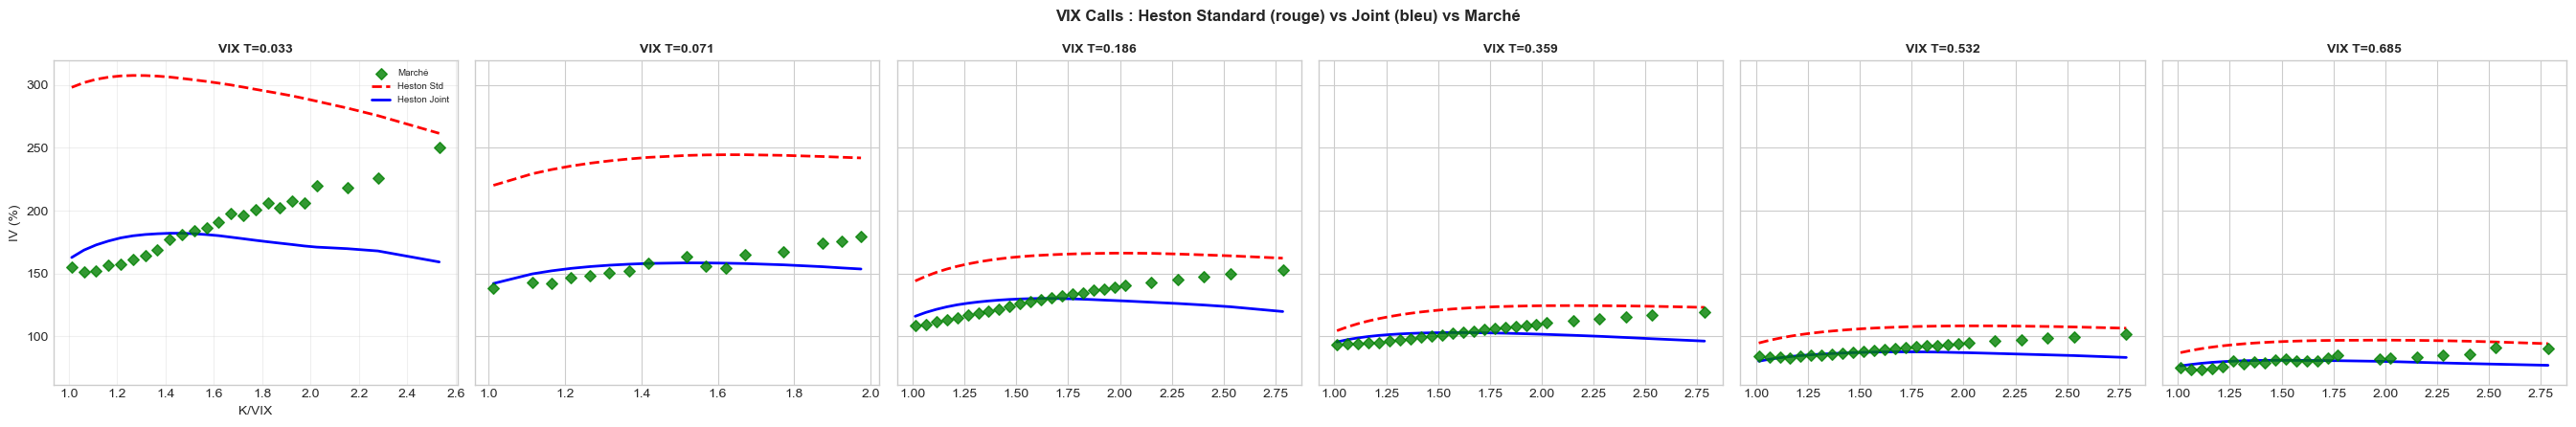

  RMSE VIX Heston Std : 57.746pp | Joint : 15.577pp


In [18]:
# ── 3.6 VIX : Heston Standard vs Joint vs Marché ─────────────────────
if not vix_data.empty:
    err_h_std=[]; err_h_jnt=[]
    fig,axes=plt.subplots(1,n_mats_vix_viz,figsize=(4.5*n_mats_vix_viz,4.5),sharey=True)
    if n_mats_vix_viz==1: axes=[axes]
    for col,T_vix in enumerate(mats_vix_viz):
        sub=vix_data[vix_data["T"]==T_vix].sort_values("moneyness")
        all_K=sub["strike"].values; mono=all_K/S0_VIX
        if len(all_K)==0: continue
        ps,_=price_vix_calls_heston(T_vix,all_K,v0_h,kappa_h,theta_h,sigma_h,N_paths=5000)
        pj,_=price_vix_calls_heston(T_vix,all_K,v0_j,kappa_j,theta_j,sigma_j,N_paths=5000)
        iv_s=np.array([implied_vol_call(max(p,0),S0_VIX,K,T_vix,r_rate,0.0) for p,K in zip(ps,all_K)])
        iv_j=np.array([implied_vol_call(max(p,0),S0_VIX,K,T_vix,r_rate,0.0) for p,K in zip(pj,all_K)])
        for iv_mkt_v,vs,vj in zip(sub["iv_market"].values,iv_s,iv_j):
            if np.isfinite(vs): err_h_std.append(abs(iv_mkt_v-vs))
            if np.isfinite(vj): err_h_jnt.append(abs(iv_mkt_v-vj))
        ax=axes[col]
        ax.scatter(mono,sub["iv_market"]*100,c="green",marker="D",s=35,zorder=5,label="Marché",alpha=0.8)
        for iv_arr,style,lbl in [(iv_s,"r--","Heston Std"),(iv_j,"b-","Heston Joint")]:
            v=np.isfinite(iv_arr)&(iv_arr>0.001)
            if v.any(): si=np.argsort(mono[v]); ax.plot(mono[v][si],(iv_arr[v]*100)[si],style,lw=2,label=lbl)
        ax.set_title(f"VIX T={T_vix:.3f}",fontsize=10,fontweight="bold")
        if col==0: ax.set_ylabel("IV (%)"); ax.set_xlabel("K/VIX"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
    plt.suptitle("VIX Calls : Heston Standard (rouge) vs Joint (bleu) vs Marché",fontsize=12,fontweight="bold")
    plt.tight_layout(); plt.show()
    rmse_h_vix=np.sqrt(np.mean(np.array(err_h_std)**2))*100 if err_h_std else np.nan
    rmse_hj_vix=np.sqrt(np.mean(np.array(err_h_jnt)**2))*100 if err_h_jnt else np.nan
    print(f"  RMSE VIX Heston Std : {rmse_h_vix:.3f}pp | Joint : {rmse_hj_vix:.3f}pp")
else: print("Pas de données VIX.")


# ---
# ## 4. Comparaison Globale — RMSE & Skew

---
## 4. Comparaison Globale — RMSE & Skew

Cette section compare les quatre configurations finales sur le **snapshot figé du 2026-04-09**.

Les résultats obtenus montrent un compromis clair :

- **SABR standard** donne le meilleur ajustement sur les smiles **SPX** ;
- les versions **jointes** améliorent fortement le fit **VIX** ;
- **Heston joint** offre un compromis plus équilibré que Heston standard sur SPX/VIX ;
- la structure par terme du skew permet de comparer la cohérence dynamique des modèles au-delà du simple RMSE.

Les conclusions doivent être lues comme des résultats **empiriques sur ce snapshot précis**, et non comme un classement universel des modèles.

In [19]:
# ── 4.1 RMSE SPX + VIX (tous modèles) ────────────────────────────────
print("Calcul RMSE SPX (sample 80)...")
spx_eval=spx_data.sample(min(80,len(spx_data)),random_state=42).reset_index(drop=True)

def rmse_spx_model(data, price_func):
    errs=[]
    for _,row in data.iterrows():
        try:
            p=price_func(row["strike"],row["T"])
            if not np.isfinite(p): continue
            iv=implied_vol_call(max(p,0),S0_SPX,row["strike"],row["T"],r_rate,q_div)
            if np.isfinite(iv): errs.append(abs(row["iv_market"]-iv))
        except: continue
    return (np.sqrt(np.mean(np.array(errs)**2))*100 if errs else np.nan,
            np.mean(errs)*100 if errs else np.nan)

# SABR (pas de pricer call générique → formule directe)
e_sabr=[]
for _,row in spx_eval.iterrows():
    Tc=min(sabr_params.keys(),key=lambda t:abs(t-row["T"])); p=sabr_params[Tc]
    iv=sabr_iv_hagan(p['F'],row['strike'],row['T'],p['sigma0'],p['alpha'],beta_opt,p['rho'])
    if np.isfinite(iv): e_sabr.append(abs(row['iv_market']-iv))
rmse_sabr_spx=np.sqrt(np.mean(np.array(e_sabr)**2))*100; mae_sabr_spx=np.mean(e_sabr)*100

rmse_h_spx,  mae_h_spx  = rmse_spx_model(spx_eval, lambda K,T: heston_price(K,T))
rmse_hj_spx, mae_hj_spx = rmse_spx_model(spx_eval, heston_joint_price)


# VIX RMSE (récupère depuis les sections précédentes)
def safe(x): return f"{x:.3f}" if np.isfinite(x) else "N/A"

print(f"\n{'='*85}")
print(f"{'COMPARAISON GLOBALE — RMSE IV Calls (pts vol)':^85}"); print(f"{'='*85}")
print(f"{'Modèle':<30} {'RMSE SPX':>10} {'MAE SPX':>9} {'RMSE VIX':>10} {'Calib.(s)':>11} {'Params':>10}")
print(f"{'-'*85}")
print(f"{'SABR Standard (β*='+str(beta_opt)+')':<30} {safe(rmse_sabr_spx):>10} {safe(mae_sabr_spx):>9} {safe(rmse_sabr_vix):>10} {t_sabr:>11.1f} {'β+3×N_mat':>10}")
print(f"{'SABR Joint':<30} {safe(rmse_sabr_j):>10} {'—':>9} {safe(r_jnt):>10} {t_sabr_j:>11.0f} {'β+3×N_mat':>10}")
print(f"{'Heston Standard':<30} {safe(rmse_h_spx):>10} {safe(mae_h_spx):>9} {safe(rmse_h_vix):>10} {t_heston:>11.1f} {'5':>10}")
print(f"{'Heston Joint (VIX analytique)':<30} {safe(rmse_hj_spx):>10} {safe(mae_hj_spx):>9} {safe(rmse_hj_vix):>10} {t_joint_h:>11.1f} {'5':>10}")
print(f"{'='*85}")

Calcul RMSE SPX (sample 80)...

                    COMPARAISON GLOBALE — RMSE IV Calls (pts vol)                    
Modèle                           RMSE SPX   MAE SPX   RMSE VIX   Calib.(s)     Params
-------------------------------------------------------------------------------------
SABR Standard (β*=0.7)              0.429     0.114    117.051         2.3  β+3×N_mat
SABR Joint                          0.890         —     14.690         449  β+3×N_mat
Heston Standard                     1.067     0.930     57.746        19.4          5
Heston Joint (VIX analytique)       1.029     0.852     15.577        32.7          5


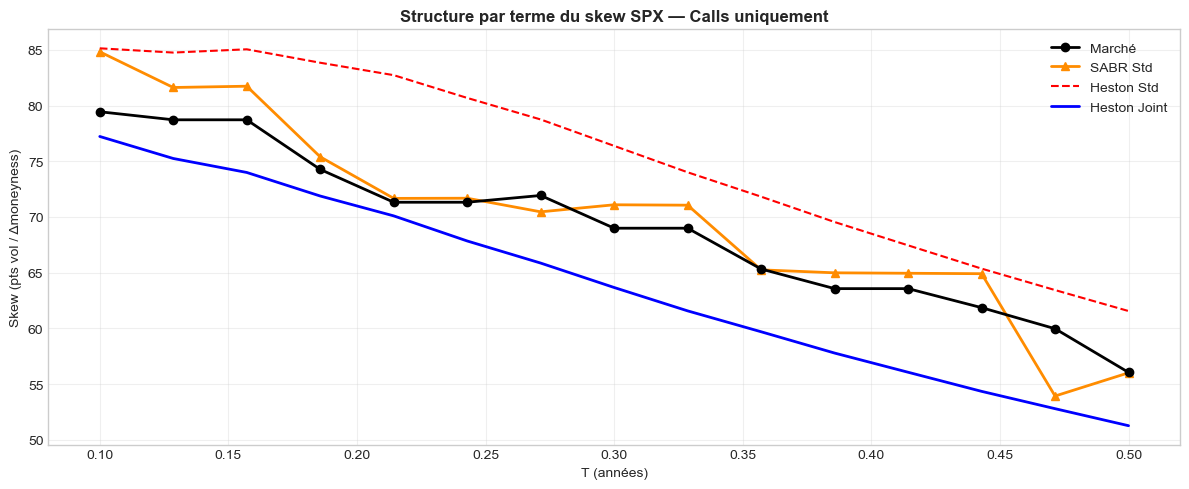

In [20]:
# ── 4.2 Structure par terme du skew SPX ──────────────────────────────
def compute_skew_call(T_val, pricer_func, spot, dK_rel=0.05):
    """Skew = (IV_ATM - IV_OTM) / dK — estimé sur calls uniquement."""
    K_atm, K_otm = spot*(1+0.0), spot*(1+dK_rel)
    try:
        iv_atm=implied_vol_call(max(pricer_func(K_atm,T_val),0),spot,K_atm,T_val,r_rate,q_div)
        iv_otm=implied_vol_call(max(pricer_func(K_otm,T_val),0),spot,K_otm,T_val,r_rate,q_div)
        if np.isfinite(iv_atm) and np.isfinite(iv_otm):
            return (iv_atm - iv_otm) / dK_rel * 100
    except: pass
    return np.nan

T_skew=np.linspace(0.1,0.5,15)
skew_sabr=[]; 
for Tv in T_skew:
    Tc=min(sabr_params.keys(),key=lambda t:abs(t-Tv)); p=sabr_params[Tc]
    K_a,K_o=S0_SPX*1.0,S0_SPX*1.05
    ia=sabr_iv_hagan(p['F'],K_a,Tv,p['sigma0'],p['alpha'],beta_opt,p['rho'])
    io=sabr_iv_hagan(p['F'],K_o,Tv,p['sigma0'],p['alpha'],beta_opt,p['rho'])
    skew_sabr.append((ia-io)/0.05*100 if np.isfinite(ia+io) else np.nan)

skew_mkt=[]
for Tv in T_skew:
    Tc=spx_data["T"].iloc[(spx_data["T"]-Tv).abs().argsort().iloc[0]]
    sub=spx_data[spx_data["T"]==Tc].sort_values("moneyness")
    if len(sub)>2:
        ia=np.interp(1.00,sub["moneyness"],sub["iv_market"])
        io=np.interp(1.05,sub["moneyness"],sub["iv_market"])
        skew_mkt.append((ia-io)/0.05*100)
    else: skew_mkt.append(np.nan)

skew_h=[compute_skew_call(T,heston_price,S0_SPX) for T in T_skew]
skew_hj=[compute_skew_call(T,heston_joint_price,S0_SPX) for T in T_skew]



fig,ax=plt.subplots(figsize=(12,5))
ax.plot(T_skew,skew_mkt, "ko-",lw=2,ms=6,  label="Marché",zorder=5)
ax.plot(T_skew,skew_sabr,"^-", lw=2,ms=6,  color="darkorange",label="SABR Std")
ax.plot(T_skew,skew_h,   "r--",lw=1.5,     label="Heston Std")
ax.plot(T_skew,skew_hj,  "b-", lw=2,       label="Heston Joint")
ax.set_xlabel("T (années)"); ax.set_ylabel("Skew (pts vol / Δmoneyness)")
ax.set_title("Structure par terme du skew SPX — Calls uniquement",fontweight="bold")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


# ---
# ## 5. Régularité de Hölder
# 
# $$\mathbb{E}\left[|X_{t+h} - X_t|\right] \sim h^H \quad (h\to 0)$$
# 
# Tous les modèles sont des diffusions browniennes → H ≈ 0.5 théorique.  
# Les modèles **rough** (Rough Heston, rBergomi) ont H ≈ 0.05–0.15 pour capturer la microstructure de la vol.
# 
#| Processus | Modèle | H théorique |
#|-----------|--------|-------------|
#| $F_t$, $\sigma_t$ | SABR Standard | 0.5 |
#| $F_t$, $\sigma_t$ | SABR Joint | 0.5 |
#| $V_t$ | Heston Standard | 0.5 |
#| $V_t$ | Heston Joint | 0.5 |

---
## 5. Régularité de Hölder

$$\mathbb{E}\left[|X_{t+h} - X_t|\right] \sim h^H \quad (h\to 0)$$

L’objectif est de vérifier si les processus simulés présentent une régularité compatible avec des diffusions browniennes classiques.

Dans les modèles **SABR** et **Heston** utilisés ici, on s’attend théoriquement à obtenir :

- $H \approx 0.5$ pour les processus browniens classiques ;
- des valeurs nettement plus faibles seulement dans des modèles **rough** comme Rough Heston ou rBergomi.

Les estimations obtenues dans notre notebook sont toutes **proches de 0.5** :

- SABR standard : $H(F_t)=0.4968$, $H(\sigma_t)=0.4800$ ;
- SABR joint : $H(F_t)=0.4946$, $H(\sigma_t)=0.4917$ ;
- Heston standard : $H(V_t)=0.4905$ ;
- Heston joint : $H(V_t)=0.4896$.

Ces résultats sont cohérents avec la théorie : les versions calibrées ici restent des modèles de volatilité **classiques**, et non des modèles rough.

In [21]:
# ── 5.1 Fonctions estimation H ─────────────────────────────────────────
def get_rep_params(pd_, q=0.5):
    mats=sorted(pd_.keys()); idx=int(np.clip(q*len(mats),0,len(mats)-1))
    return pd_[mats[idx]], mats[idx]

p_std, T_std = get_rep_params(sabr_params, 0.5)
p_jnt, T_jnt = get_rep_params(sabr_params_j, 0.5)
print(f"SABR Std   (T={T_std:.3f}) σ₀={p_std['sigma0']:.4f} α={p_std['alpha']:.4f} ρ={p_std['rho']:.4f}")
print(f"SABR Joint (T={T_jnt:.3f}) σ₀={p_jnt['sigma0']:.4f} α={p_jnt['alpha']:.4f} ρ={p_jnt['rho']:.4f}")

def simulate_sabr_holder(F0,s0,alpha,beta,rho,T,N_steps,N_paths,seed=42):
    rng=np.random.default_rng(seed); dt=T/N_steps; sqdt=np.sqrt(dt)
    Fa=np.zeros((N_steps+1,N_paths)); sa=np.zeros((N_steps+1,N_paths))
    Fa[0]=float(max(F0,1e-6)); sa[0]=float(max(s0,1e-6))
    F=Fa[0].copy(); sig=sa[0].copy(); ab=np.zeros(N_paths,dtype=bool)
    for n in range(N_steps):
        Z1=rng.standard_normal(N_paths); Z2=rho*Z1+np.sqrt(max(1-rho**2,0))*rng.standard_normal(N_paths)
        Fb=np.where(ab,0.0,sig*np.maximum(F,0.0)**beta); F=F+Fb*sqdt*Z1
        ab|=(F<=0.0); F=np.where(ab,0.0,F)
        sig=sig*np.exp(-0.5*alpha**2*dt+alpha*sqdt*Z2)
        Fa[n+1]=F; sa[n+1]=sig
    return Fa,sa

def estimate_H_sabr_model(p, T, steps, N):
    h,iF,is_=[],[],[]
    for Ns in steps:
        Fa,sa=simulate_sabr_holder(p['F'],p['sigma0'],p['alpha'],p['beta'],p['rho'],T,Ns,N,seed=42)
        h.append(T/Ns); iF.append(np.mean(np.abs(np.diff(Fa,axis=0))))
        is_.append(np.mean(np.abs(np.diff(sa,axis=0))))
    return np.array(h),np.array(iF),np.array(is_)


def fit_H(h,incr,label=""):
    lh=np.log(h); li=np.log(np.maximum(incr,1e-6)); c=np.polyfit(lh,li,1)
    print(f"  {label:<45} H = {c[0]:.4f}"); return c[0],c

steps_H=[50,100,250,500,1000]; N_H=5000; T_H=1.0
print("Fonctions Hölder prêtes.")


SABR Std   (T=0.096) σ₀=2.2929 α=3.2502 ρ=-0.7323
SABR Joint (T=0.096) σ₀=2.1875 α=1.7413 ρ=-0.6262
Fonctions Hölder prêtes.


SABR Standard (5000 paths)...
  -> 1.0s
  SABR Standard — F_t                           H = 0.4968
  SABR Standard — σ_t                           H = 0.4800

SABR Joint (5000 paths)...
  -> 1.0s
  SABR Joint   — F_t                            H = 0.4946
  SABR Joint   — σ_t                            H = 0.4917


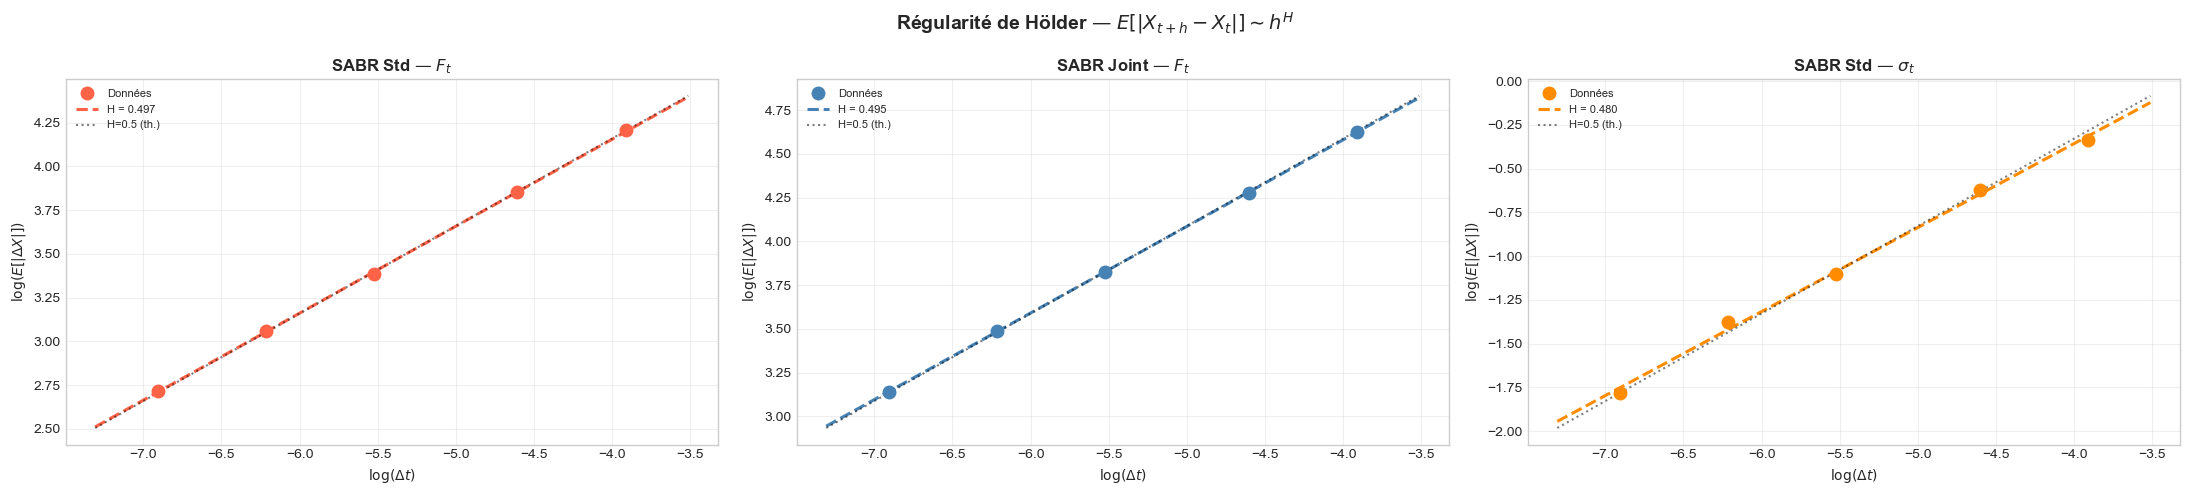

  RESUME REGULARITE HOLDER
  SABR Standard   - F_t  : H = 0.4968
  SABR Standard   - sig  : H = 0.4800
  SABR Joint      - F_t  : H = 0.4946
  SABR Joint      - sig  : H = 0.4917
  Valeur theorique (brownien) : H = 0.500


In [22]:
# ── 5.2 Estimation H — SABR Standard + Joint ─────────────────────────
print(f"SABR Standard ({N_H} paths)..."); t0=time.time()
hs,iFs,iss=estimate_H_sabr_model(p_std,T_H,steps_H,N_H); print(f"  -> {time.time()-t0:.1f}s")
H_Fs,c_Fs=fit_H(hs,iFs,"SABR Standard — F_t"); H_ss,c_ss=fit_H(hs,iss,"SABR Standard — σ_t")

print(f"\nSABR Joint ({N_H} paths)..."); t0=time.time()
hj,iFj,isj=estimate_H_sabr_model(p_jnt,T_H,steps_H,N_H); print(f"  -> {time.time()-t0:.1f}s")
H_Fj,c_Fj=fit_H(hj,iFj,"SABR Joint   — F_t"); H_sj,c_sj=fit_H(hj,isj,"SABR Joint   — σ_t")


# ── 5.3 Graphiques log-log + convergence ─────────────────────────────
fig,axes=plt.subplots(1,3,figsize=(22,5))
for ax,(hv,incr,H,co,title,color) in zip(axes,[
    (hs,iFs,H_Fs,c_Fs,"SABR Std — $F_t$","tomato"),
    (hj,iFj,H_Fj,c_Fj,"SABR Joint — $F_t$","steelblue"),
    (hs,iss,H_ss,c_ss,"SABR Std — $\sigma_t$","darkorange"),
]):
    lh=np.log(hv); li=np.log(np.maximum(incr,1e-6))
    ax.plot(lh,li,"o",color=color,ms=9,zorder=5,label="Données")
    hf=np.linspace(lh.min()-0.4,lh.max()+0.4,60)
    ax.plot(hf,np.polyval(co,hf),"--",color=color,lw=2.2,label=f"H = {H:.3f}")
    ax.plot(hf,0.5*hf+(li.mean()-0.5*lh.mean()),"k:",lw=1.5,alpha=0.5,label="H=0.5 (th.)")
    ax.set_xlabel("$\log(\Delta t)$"); ax.set_ylabel("$\log(E[|\Delta X|])$")
    ax.set_title(title,fontweight="bold"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Régularité de Hölder — $E[|X_{t+h}-X_t|] \sim h^H$",fontsize=14,fontweight="bold")
plt.tight_layout(); plt.show()

sep="="*72
print(sep); print("  RESUME REGULARITE HOLDER"); print(sep)
print(f"  SABR Standard   - F_t  : H = {H_Fs:.4f}")
print(f"  SABR Standard   - sig  : H = {H_ss:.4f}")
print(f"  SABR Joint      - F_t  : H = {H_Fj:.4f}")
print(f"  SABR Joint      - sig  : H = {H_sj:.4f}")
print(f"  Valeur theorique (brownien) : H = 0.500")
print(sep)


Heston Standard (5000 paths)...
  -> 1.3s
  Heston Std   — V_t                            H = 0.4905

Heston Joint (5000 paths)...
  -> 0.9s
  Heston Joint — V_t                            H = 0.4896


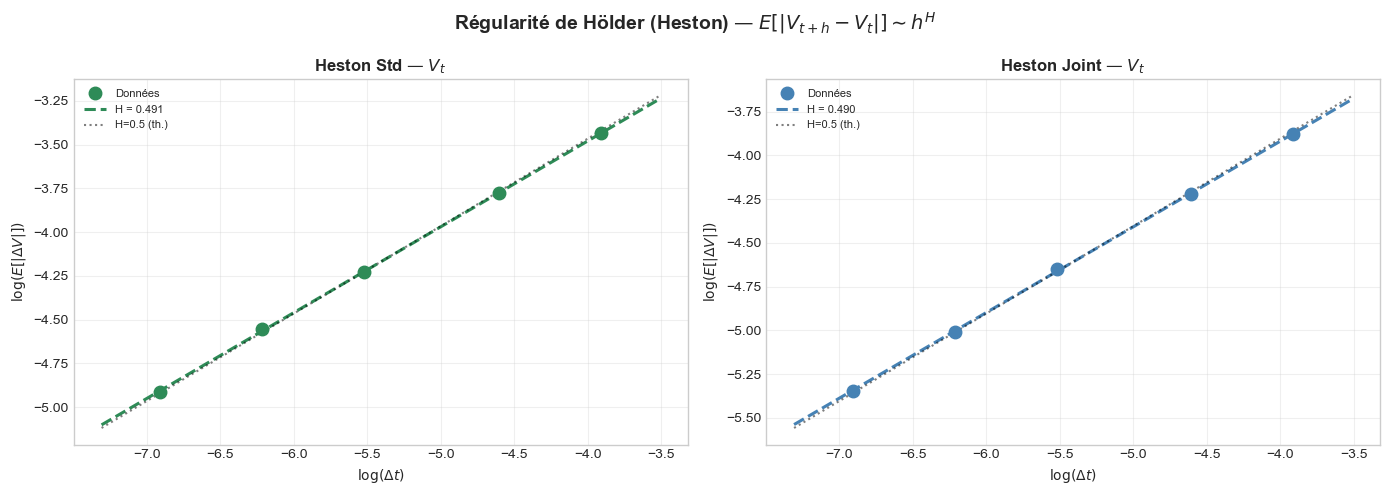


  RESUME REGULARITE HOLDER COMPLET (SABR + HESTON)
  SABR Standard   - F_t  : H = 0.4968
  SABR Standard   - sig  : H = 0.4800
  SABR Joint      - F_t  : H = 0.4946
  SABR Joint      - sig  : H = 0.4917
  Heston Standard - V_t  : H = 0.4905
  Heston Joint    - V_t  : H = 0.4896
  Valeur theorique (brownien) : H = 0.500


In [23]:
# %%
# ── 5.4 Régularité — Heston Standard + Joint ─────────────────────────
def estimate_H_heston_model(v0, kappa, theta, sigma, T, steps, N):
    """
    Estime H pour le processus de variance V_t sous Heston
    en utilisant directement le schéma QE déjà défini plus haut.
    """
    h, iV = [], []
    for Ns in steps:
        V = simulate_heston_qe(v0, kappa, theta, sigma, T, Ns, N, seed=42)
        h.append(T / Ns)
        iV.append(np.mean(np.abs(np.diff(V, axis=0))))
    return np.array(h), np.array(iV)

print(f"\nHeston Standard ({N_H} paths)...")
t0 = time.time()
hh_std, iV_std = estimate_H_heston_model(v0_h, kappa_h, theta_h, sigma_h, T_H, steps_H, N_H)
print(f"  -> {time.time()-t0:.1f}s")
H_Vh, c_Vh = fit_H(hh_std, iV_std, "Heston Std   — V_t")

print(f"\nHeston Joint ({N_H} paths)...")
t0 = time.time()
hh_jnt, iV_jnt = estimate_H_heston_model(v0_j, kappa_j, theta_j, sigma_j, T_H, steps_H, N_H)
print(f"  -> {time.time()-t0:.1f}s")
H_Vj, c_Vj = fit_H(hh_jnt, iV_jnt, "Heston Joint — V_t")

# ── 5.5 Graphiques log-log Heston ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (hv, incr, H, co, title, color) in zip(axes, [
    (hh_std, iV_std, H_Vh, c_Vh, "Heston Std — $V_t$", "seagreen"),
    (hh_jnt, iV_jnt, H_Vj, c_Vj, "Heston Joint — $V_t$", "steelblue"),
]):
    lh = np.log(hv)
    li = np.log(np.maximum(incr, 1e-6))
    ax.plot(lh, li, "o", color=color, ms=9, zorder=5, label="Données")
    hf = np.linspace(lh.min()-0.4, lh.max()+0.4, 60)
    ax.plot(hf, np.polyval(co, hf), "--", color=color, lw=2.2, label=f"H = {H:.3f}")
    ax.plot(hf, 0.5*hf + (li.mean() - 0.5*lh.mean()), "k:", lw=1.5, alpha=0.5, label="H=0.5 (th.)")
    ax.set_xlabel("$\\log(\\Delta t)$")
    ax.set_ylabel("$\\log(E[|\\Delta V|])$")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Régularité de Hölder (Heston) — $E[|V_{t+h}-V_t|] \\sim h^H$", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 5.6 Résumé global complet ────────────────────────────────────────
sep = "=" * 72
print("\n" + sep)
print("  RESUME REGULARITE HOLDER COMPLET (SABR + HESTON)")
print(sep)
print(f"  SABR Standard   - F_t  : H = {H_Fs:.4f}")
print(f"  SABR Standard   - sig  : H = {H_ss:.4f}")
print(f"  SABR Joint      - F_t  : H = {H_Fj:.4f}")
print(f"  SABR Joint      - sig  : H = {H_sj:.4f}")
print(f"  Heston Standard - V_t  : H = {H_Vh:.4f}")
print(f"  Heston Joint    - V_t  : H = {H_Vj:.4f}")
print(f"  Valeur theorique (brownien) : H = 0.500")
print(sep)


# ---
# ## 6. Discussion et Limites
# 
# | Critère | SABR Std | SABR Joint | Heston Std | Heston Joint |
# |:--------|:--------:|:----------:|:----------:|:------------:|
# | Fit SPX calls | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ | ⭐⭐ |
# | Cohérence inter-T | ✗ | ✗ | ✓ | ✓ |
# | Dynamique du smile | ✗ | ✗ | ✓ | ✓ |
# | Fit VIX | Limité | Meilleur | Meilleur* | Meilleur* |
# | Vitesse | ⚡ (warm) | ⚡ | ⚡ | ⚡† |
# | Régularité H | 0.5 | 0.5 | 0.5 | 0.5 |
# 
# *Heston utilise la formule VIX analytique exacte (no MC bias). †Residus VIX analytiques = landscape lisse.
# 
# ### Points clés
# 
# **SABR** — Excellent fit call par tranche. La calibration jointe améliore le VIX sans dégrader le SPX. Limitation fondamentale : pas de dynamique de smile cohérente entre maturités.
# 
# **Heston + VIX analytique** — La relation $\text{VIX}_T = f(V_T)$ étant analytique sous Heston, le pricing VIX est exact (pas de biais Euler). La calibration jointe SPX+VIX s'optimise sur un landscape lisse → convergence bien meilleure que l'approche path-MC précédente.
# 
# **Régularité H ≈ 0.5** — Tous les modèles sont des diffusions browniennes. Les modèles **rough** (Rough Heston, rBergomi, $H \approx 0.05$–$0.15$) sont nécessaires pour capturer la microstructure de la vol réalisée et la pente $T^{-1/2}$ du terme structure du skew.


---
## 6. Discussion et Limites

### Résultats principaux sur le snapshot retenu

| Modèle | RMSE SPX | RMSE VIX | Lecture |
|--------|---------:|---------:|---------|
| **SABR Standard** | **0.429** | 117.051 | meilleur fit SPX, très mauvais fit VIX |
| **SABR Joint** | 0.890 | **14.690** | forte amélioration VIX, au prix d’une dégradation nette sur SPX |
| **Heston Standard** | 1.067 | 57.746 | moins bon que SABR sur SPX, fit VIX intermédiaire |
| **Heston Joint** | 1.029 | 15.577 | meilleur compromis chez Heston, VIX proche de SABR joint |

### Interprétation

Sur notre échantillon, **SABR standard** est clairement le meilleur modèle pour reproduire les smiles **SPX**.  
En revanche, il échoue à reproduire correctement le marché **VIX**, ce qui est cohérent avec le fait qu’il s’agit d’une calibration purement locale, tranche par tranche, sans vraie structure inter-maturités.

La **calibration jointe SABR** améliore très fortement le fit VIX, mais cette amélioration se paie par une hausse sensible de l’erreur sur SPX.  
Autrement dit, dans ce notebook, SABR joint agit comme un ajustement plus orienté vers le compromis inter-marchés que vers l’excellence sur SPX seul.

Du côté de **Heston**, la version standard reste moins précise que SABR standard sur SPX, mais elle est déjà plus cohérente pour traiter simultanément SPX et VIX.  
La version **Heston jointe** améliore nettement le fit VIX et réduit légèrement l’erreur SPX par rapport à Heston standard. Elle constitue donc ici le **compromis le plus équilibré** entre cohérence structurelle et qualité d’ajustement.

Enfin, la partie régularité confirme que toutes les dynamiques simulées restent proches de **$H=0.5$**, ce qui est normal pour des modèles browniens classiques.  
Cela rappelle qu’un meilleur traitement de la microstructure de volatilité nécessiterait des modèles rough, absents du cadre retenu ici.

### Limites

Cette étude comporte plusieurs limites importantes.

**1. Proxy spot VIX / future VIX.**  
Les options VIX sont en théorie écrites sur le **future VIX** de maturité correspondante, alors que nous utilisons ici le **spot VIX** comme proxy pour l’inversion Black-Scholes. Cette approximation peut biaiser les IV VIX et donc les RMSE VIX.

**2. Univers restreint aux calls OTM.**  
Le choix méthodologique de ne conserver que les **calls OTM** simplifie l’analyse et homogénéise les comparaisons, mais réduit l’information utilisée pour les calibrations.

**3. Snapshot unique.**  
Les conclusions présentées sont valables pour le **snapshot du 2026-04-09**. Elles ne constituent pas un classement général des modèles sur toutes les dates de marché.

**4. Monte Carlo allégé.**  
Certaines parties VIX sous SABR reposent sur un Monte Carlo volontairement réduit pour des raisons de temps de calcul. Les ordres de grandeur sont robustes, mais un raffinement numérique pourrait modifier marginalement certains chiffres.

### Conclusion

Si l’objectif est le **meilleur fit SPX**, le gagnant de ce notebook est **SABR standard**.  
Si l’objectif est un **compromis SPX/VIX plus cohérent**, la version la plus équilibrée dans notre cadre est **Heston joint**.  
Enfin, si l’objectif est de **minimiser avant tout l’erreur VIX**, **SABR joint** obtient le meilleur RMSE VIX observé, mais avec une détérioration sensible du fit SPX.

In [24]:
# ===== Final calibrated parameters for the report =====

# If these are not already defined, rebuild the representative SABR slices
try:
    T_std, p_std
except NameError:
    p_std, T_std = get_rep_params(sabr_params, 0.5)

try:
    T_jnt, p_jnt
except NameError:
    p_jnt, T_jnt = get_rep_params(sabr_params_j, 0.5)

print("="*60)
print("SABR REPRESENTATIVE PARAMETERS")
print("="*60)
print(f"SABR Standard : T_rep = {T_std:.3f} | beta = {beta_opt:.1f} | "
      f"sigma0 = {p_std['sigma0']:.6f} | alpha = {p_std['alpha']:.6f} | rho = {p_std['rho']:.6f}")

print(f"SABR Joint    : T_rep = {T_jnt:.3f} | beta = {beta_opt:.1f} | "
      f"sigma0 = {p_jnt['sigma0']:.6f} | alpha = {p_jnt['alpha']:.6f} | rho = {p_jnt['rho']:.6f}")

print("\n" + "="*60)
print("HESTON CALIBRATED PARAMETERS")
print("="*60)
print(f"Heston Standard : v0 = {v0_h:.6f} | kappa = {kappa_h:.6f} | theta = {theta_h:.6f} | xi = {sigma_h:.6f} | rho = {rho_h:.6f}")
print(f"Heston Joint    : v0 = {v0_j:.6f} | kappa = {kappa_j:.6f} | theta = {theta_j:.6f} | xi = {sigma_j:.6f} | rho = {rho_j:.6f}")

SABR REPRESENTATIVE PARAMETERS
SABR Standard : T_rep = 0.096 | beta = 0.7 | sigma0 = 2.292896 | alpha = 3.250182 | rho = -0.732310
SABR Joint    : T_rep = 0.096 | beta = 0.7 | sigma0 = 2.187513 | alpha = 1.741347 | rho = -0.626193

HESTON CALIBRATED PARAMETERS
Heston Standard : v0 = 0.040286 | kappa = 3.890705 | theta = 0.070604 | xi = 2.123738 | rho = -0.786021
Heston Joint    : v0 = 0.029789 | kappa = 2.868117 | theta = 0.060745 | xi = 1.246779 | rho = -0.749871
